# Peramalan IHSG dengan Kombinasi Algoritma Genetika dan Jaringan Saraf Tiruan

Notebook ini mengimplementasikan model GANN, GADAM, dan ADAM untuk peramalan Indeks Harga Saham Gabungan (IHSG) menggunakan *time series cross validation* dengan 4 *fold*.

Metrik evaluasi (RMSE, MAE, MAPE) dihitung untuk setiap *fold*, dan hasil disimpan dalam format CSV serta visualisasi grafik.

## 1. Import Libraries dan Setup
Mengimpor pustaka yang diperlukan dan mengatur seed untuk reproduktibilitas.

In [1]:
pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 kB 689.0 kB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import LearningRateScheduler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
import seaborn as sns
from deap import base, creator, tools, algorithms
import random
import warnings
import os
warnings.filterwarnings('ignore')

# Set seed untuk reproduktibilitas
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

os.makedirs('models', exist_ok=True)
os.makedirs('docs', exist_ok=True)

%matplotlib inline

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Fungsi Utilitas
Mendefinisikan fungsi utilitas yang diperlukan untuk pelatihan, evaluasi, dan visualisasi.

In [4]:
def lr_scheduler(epoch, lr):
    """Scheduler untuk mengurangi learning rate setelah 50 epoch."""
    if epoch > 50:
        return lr * 0.95 ** ((epoch - 50) // 20)
    return lr

def build_ann_model(input_dim, hidden_neurons, use_dropout=False, use_l2=False):
    """Membangun model ANN dengan parameter yang diberikan."""
    initializer = 'glorot_uniform'
    model = Sequential([
        Dense(hidden_neurons, input_dim=input_dim, activation='relu',
              kernel_initializer=initializer,
              kernel_regularizer=tf.keras.regularizers.l2(L2_LAMBDA) if use_l2 else None),
        Dropout(DROPOUT_RATE) if use_dropout else tf.keras.layers.Lambda(lambda x: x),
        Dense(1, activation='linear',
              kernel_regularizer=tf.keras.regularizers.l2(L2_LAMBDA) if use_l2 else None)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='mse')
    return model

def set_model_weights(model, weights):
    """Mengatur bobot model dari vektor weights untuk GA."""
    w1_size = INPUT_DIM * HIDDEN_NEURONS
    w1 = np.array(weights[:w1_size]).reshape(INPUT_DIM, HIDDEN_NEURONS)
    b1 = np.array(weights[w1_size:w1_size + HIDDEN_NEURONS])
    w2 = np.array(weights[w1_size + HIDDEN_NEURONS:w1_size + 2 * HIDDEN_NEURONS]).reshape(HIDDEN_NEURONS, 1)
    b2 = np.array([weights[-1]])
    model.layers[0].set_weights([w1, b1])
    model.layers[2].set_weights([w2, b2])

def evaluate_individual(individual, model, X, y):
    """Menghitung fitness individu berdasarkan RMSE untuk GA."""
    set_model_weights(model, individual)
    predictions = model.predict(X, verbose=0).flatten()
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mse)
    return (1.0 / (rmse + 1e-10),)

def calculate_metrics(y_true, y_pred):
    """Menghitung metrik evaluasi (RMSE, MAE, MAPE)."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    return rmse, mae, mape

def normalize_data(data, min_val, max_val):
    """Normalisasi data ke [0, 1] menggunakan min-max scaling."""
    return (data - min_val) / (max_val - min_val + 1e-10)

def denormalize_data(data, min_val, max_val):
    """Mendenormalisasi data dari [0, 1] ke skala asli."""
    return data * (max_val - min_val + 1e-10) + min_val

def glorot_init(input_dim, hidden_neurons):
    """Membuat inisialisasi bobot dengan rentang Glorot untuk GA."""
    limit_w1 = np.sqrt(6 / (input_dim + hidden_neurons))
    limit_w2 = np.sqrt(6 / (hidden_neurons + 1))
    weights = []
    for _ in range(input_dim * hidden_neurons):
        weights.append(random.uniform(-limit_w1, limit_w1))
    for _ in range(hidden_neurons):
        weights.append(0.0)
    for _ in range(hidden_neurons):
        weights.append(random.uniform(-limit_w2, limit_w2))
    weights.append(0.0)
    return weights

class EpochLogger(tf.keras.callbacks.Callback):
    def __init__(self, fold, model_type):
        super().__init__()
        self.fold = fold
        self.model_type = model_type

    def on_epoch_end(self, epoch, logs=None):
        train_loss = logs.get('loss')
        val_loss = logs.get('val_loss')
        print(f"Fold {self.fold} - {self.model_type} - Epoch {epoch + 1}: Loss Latih = {train_loss:.6f}, Loss Validasi = {val_loss:.6f}")

## 3. Load dan Persiapan Data
Memuat data IHSG dan membagi data dengan cross validation

In [5]:
# Input data
INPUT_FILE = '/content/drive/MyDrive/penelitian/data_jkse_eda_final.csv'

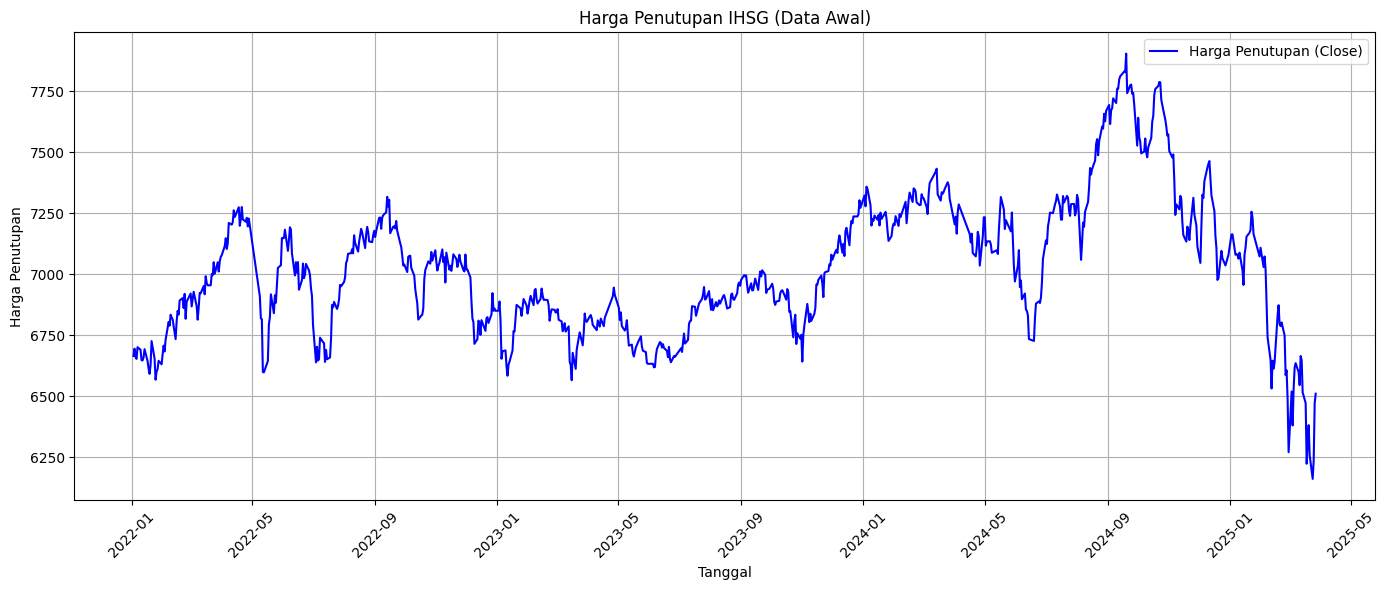

In [6]:
# Load data
df = pd.read_csv(INPUT_FILE)
df['Date'] = pd.to_datetime(df['Date'])
close_values = df['Close'].values
dates = df['Date'].values

# Visualisasi data awal
plt.figure(figsize=(14, 6))
plt.plot(dates, close_values, label='Harga Penutupan (Close)', color='blue')
plt.title('Harga Penutupan IHSG (Data Awal)')
plt.xlabel('Tanggal')
plt.ylabel('Harga Penutupan')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'docs/ihsg_data_initial.png')
plt.show()


--- Fold 1 ---
Train Data (158 data points): 2022-01-03 to 2022-08-30, Min: 6568.17, Max: 7276.19
Test Data (156 data points):  2022-08-31 to 2023-04-11, Min: 6565.73, Max: 7318.02


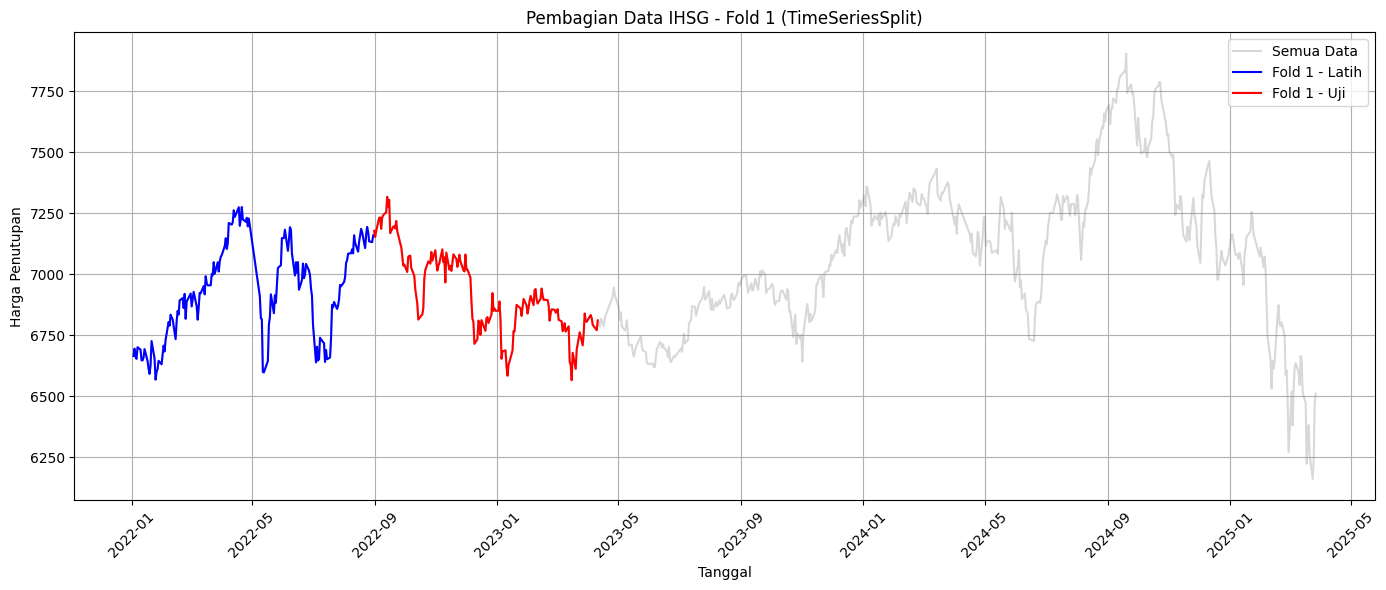


--- Fold 2 ---
Train Data (314 data points): 2022-01-03 to 2023-04-11, Min: 6565.73, Max: 7318.02
Test Data (156 data points):  2023-04-12 to 2023-12-06, Min: 6618.92, Max: 7100.85


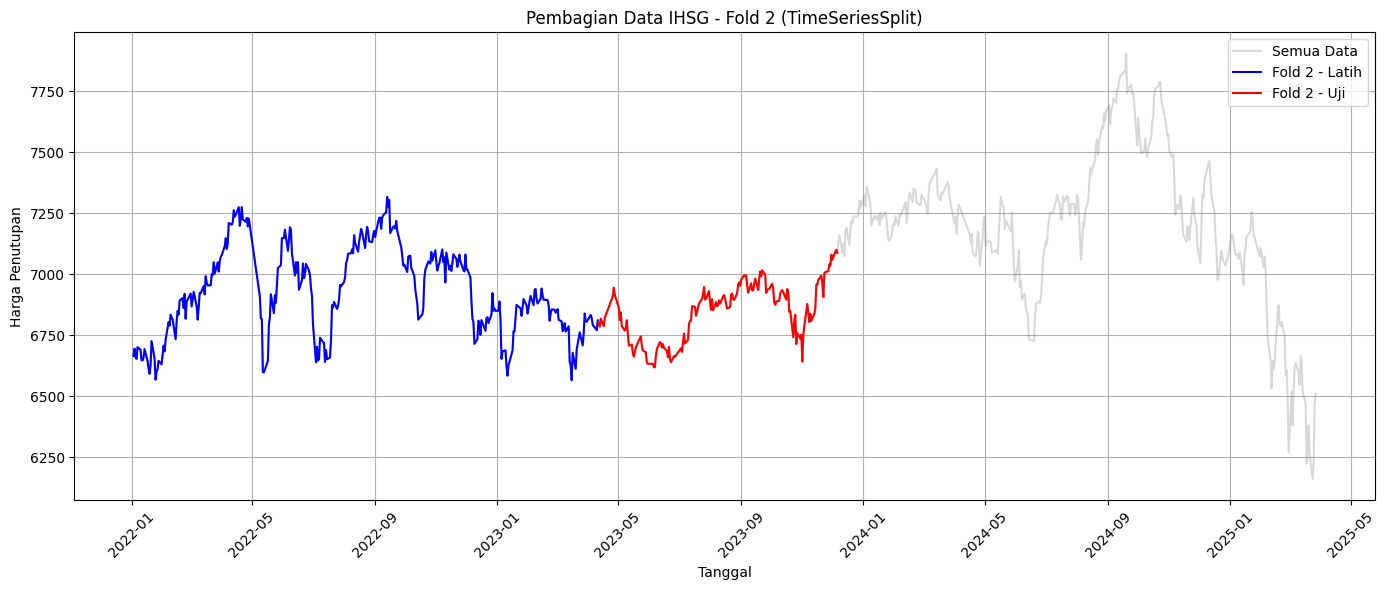


--- Fold 3 ---
Train Data (470 data points): 2022-01-03 to 2023-12-06, Min: 6565.73, Max: 7318.02
Test Data (156 data points):  2023-12-07 to 2024-08-08, Min: 6726.92, Max: 7433.31


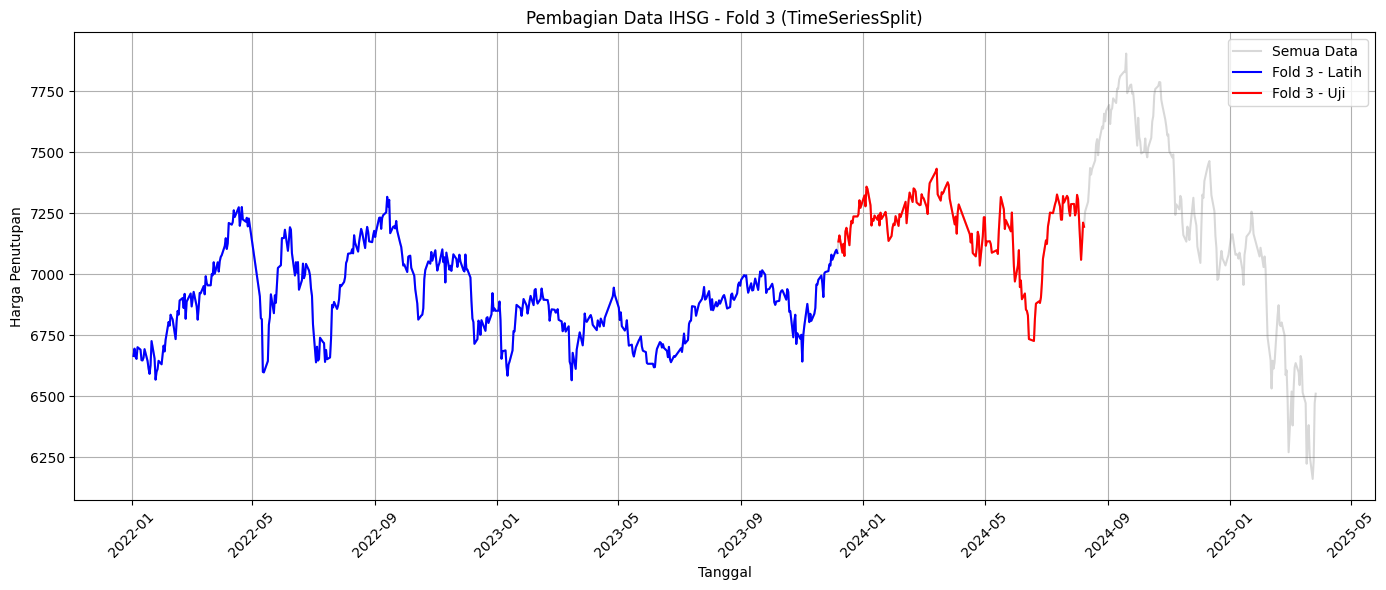


--- Fold 4 ---
Train Data (626 data points): 2022-01-03 to 2024-08-08, Min: 6565.73, Max: 7433.31
Test Data (156 data points):  2024-08-09 to 2025-03-27, Min: 6161.22, Max: 7905.39


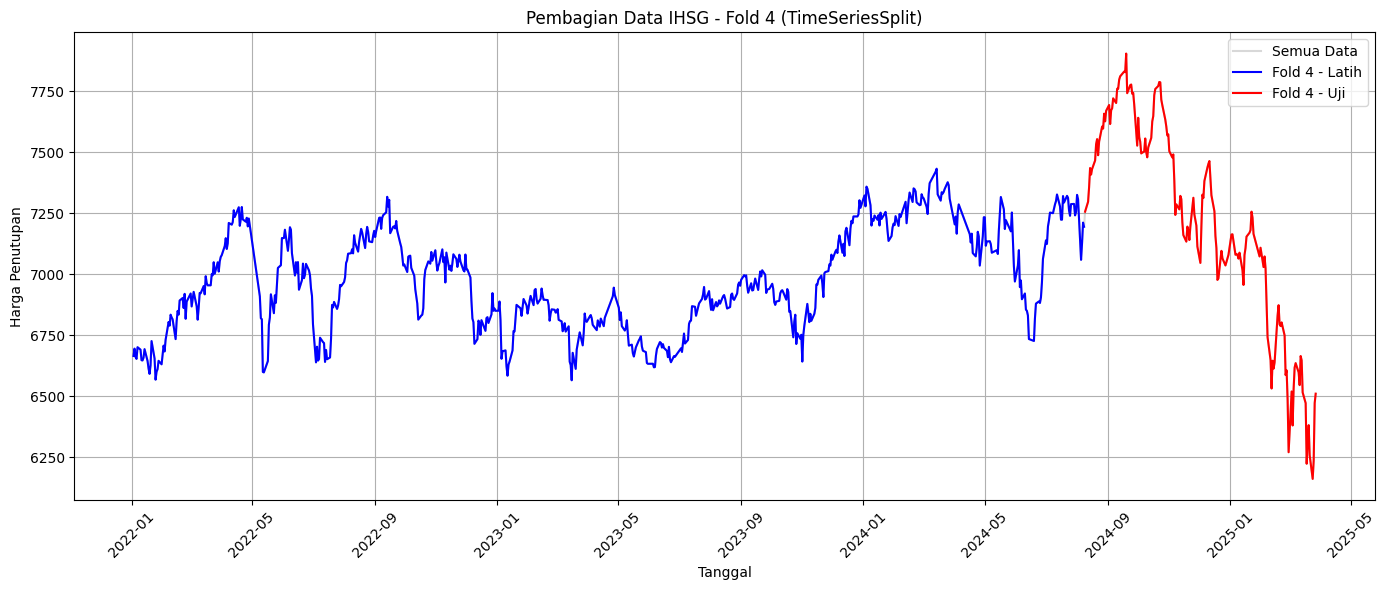

In [7]:
# Inisialisasi TimeSeriesSplit
N_SPLITS = 4
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
for fold, (train_idx, test_idx) in enumerate(tscv.split(close_values), 1):
    train_dates = dates[train_idx]
    test_dates = dates[test_idx]
    train_close = close_values[train_idx]
    test_close = close_values[test_idx]

    print(f"\n--- Fold {fold} ---")
    print(f"Train Data ({len(train_idx)} data points): {pd.Timestamp(train_dates[0]).strftime('%Y-%m-%d')} to {pd.Timestamp(train_dates[-1]).strftime('%Y-%m-%d')}, Min: {train_close.min():.2f}, Max: {train_close.max():.2f}")
    print(f"Test Data ({len(test_idx)} data points):  {pd.Timestamp(test_dates[0]).strftime('%Y-%m-%d')} to {pd.Timestamp(test_dates[-1]).strftime('%Y-%m-%d')}, Min: {test_close.min():.2f}, Max: {test_close.max():.2f}")


    plt.figure(figsize=(14, 6))
    plt.plot(dates, close_values, color='gray', alpha=0.3, label='Semua Data')
    plt.plot(train_dates, train_close, color='blue', label=f'Fold {fold} - Latih')
    plt.plot(test_dates, test_close, color='red', label=f'Fold {fold} - Uji')
    plt.title(f'Pembagian Data IHSG - Fold {fold} (TimeSeriesSplit)')
    plt.xlabel('Tanggal')
    plt.ylabel('Harga Penutupan')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'docs/ihsg_fold_{fold}_split.png')
    plt.show()

## 4. Analisis ACF - PACF
Melakukan analisis ACF dan  PACF di masing masing fold untuk menentukan input ANN.


--- Analisis ACF dan PACF untuk Data Latih Fold 1 ---


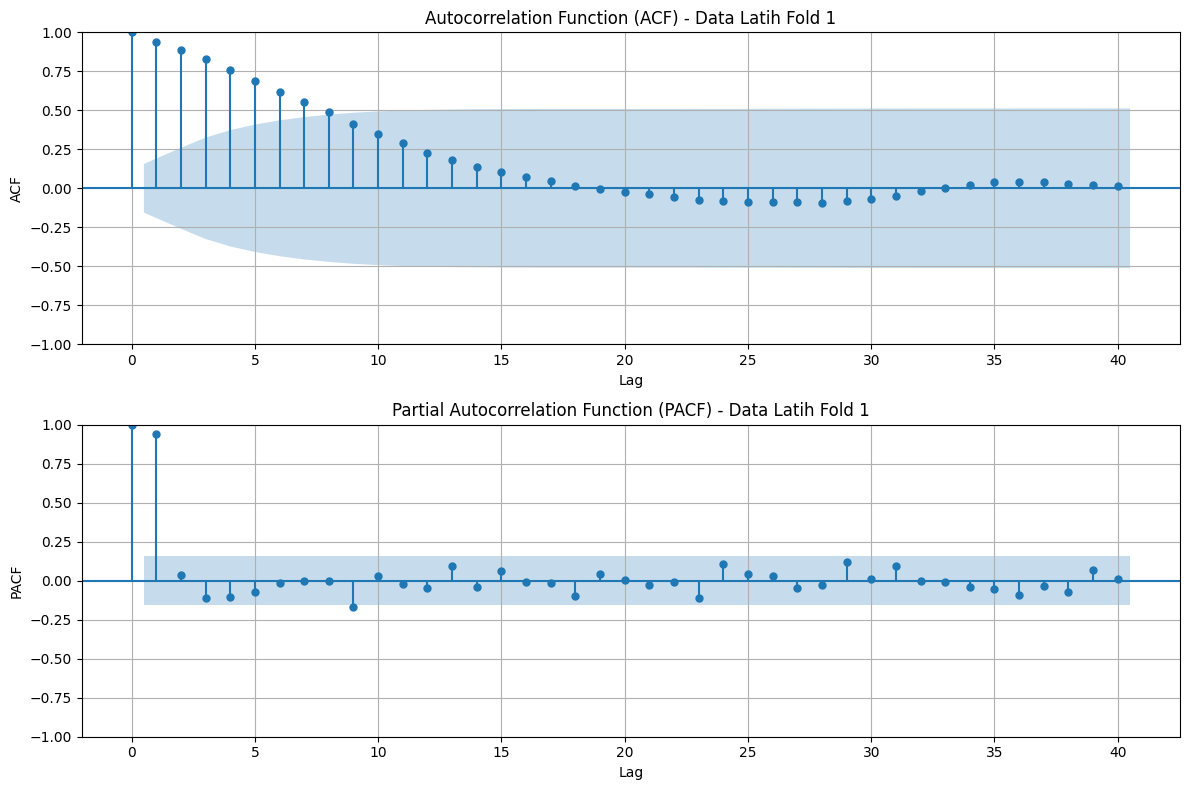


--- Analisis ACF dan PACF untuk Data Latih Fold 2 ---


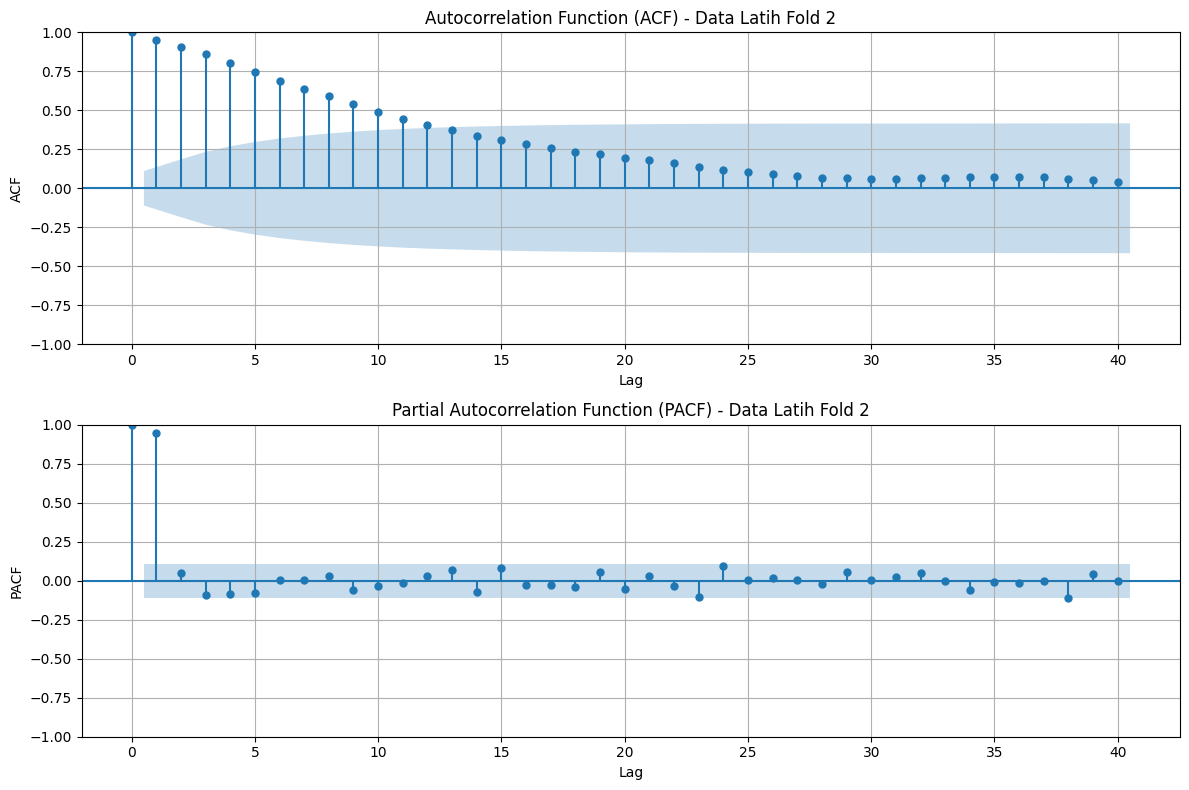


--- Analisis ACF dan PACF untuk Data Latih Fold 3 ---


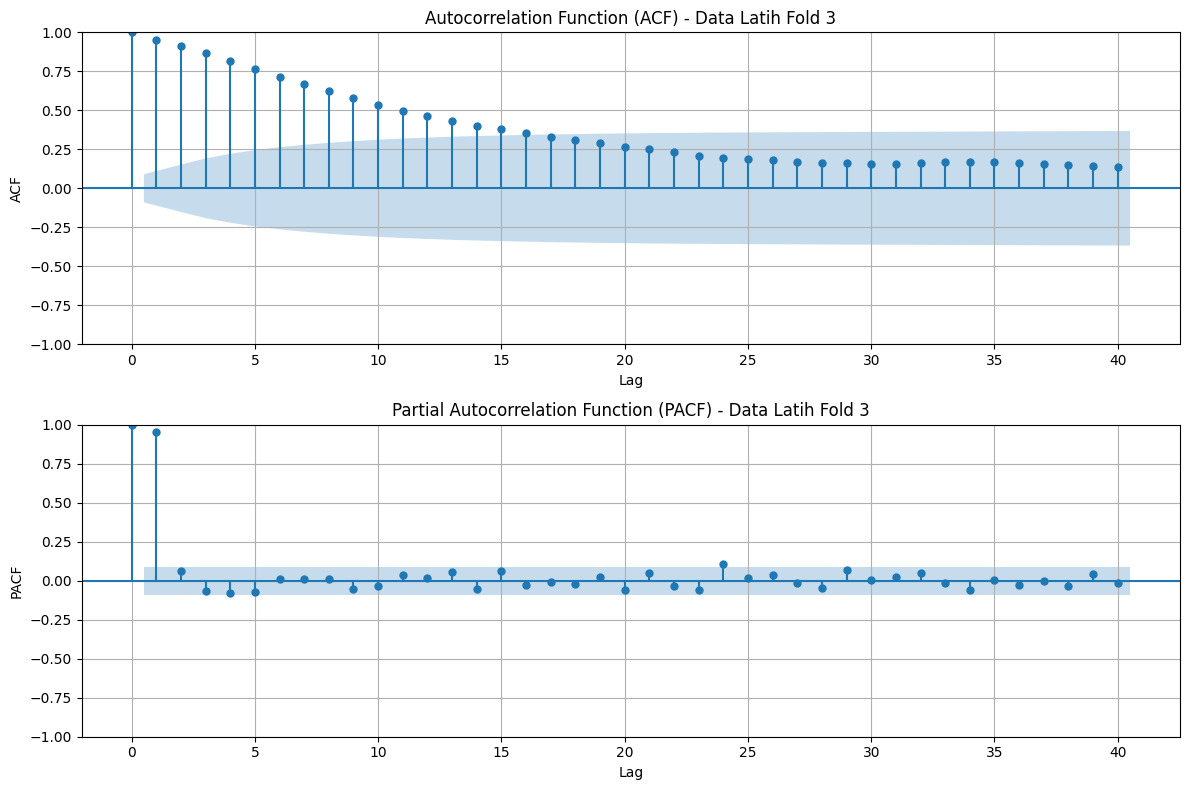


--- Analisis ACF dan PACF untuk Data Latih Fold 4 ---


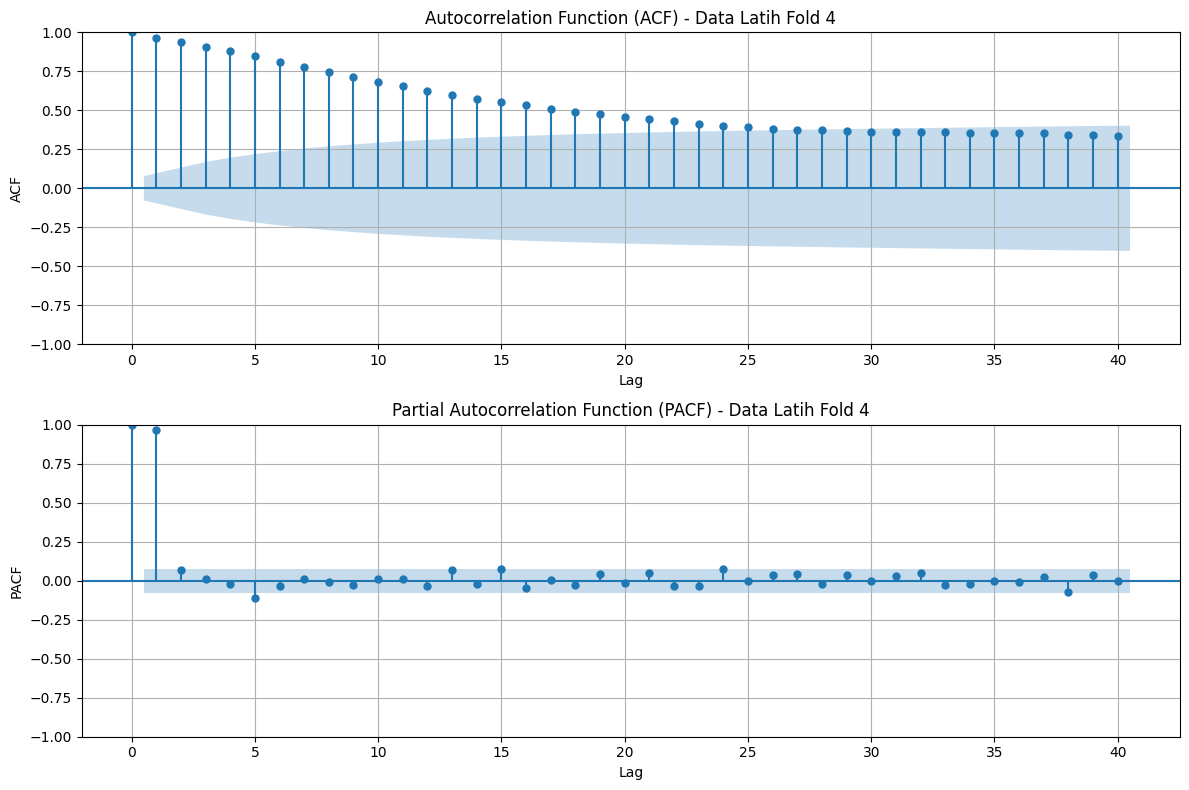

In [8]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

for fold, (train_idx, test_idx) in enumerate(tscv.split(close_values), 1):
    train_close = close_values[train_idx]

    print(f"\n--- Analisis ACF dan PACF untuk Data Latih Fold {fold} ---")

    # Membuat layout untuk dua plot (2 baris, 1 kolom)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot ACF pada subplot pertama
    plot_acf(train_close, ax=ax1, lags=40)
    ax1.set_title(f'Autocorrelation Function (ACF) - Data Latih Fold {fold}')
    ax1.set_xlabel('Lag')
    ax1.set_ylabel('ACF')
    ax1.grid(True)

    # Plot PACF pada subplot kedua
    plot_pacf(train_close, ax=ax2, lags=40)
    ax2.set_title(f'Partial Autocorrelation Function (PACF) - Data Latih Fold {fold}')
    ax2.set_xlabel('Lag')
    ax2.set_ylabel('PACF')
    ax2.grid(True)

    # Menampilkan dan menyimpan plot untuk setiap fold
    plt.tight_layout() # Merapikan layout agar judul tidak tumpang tindih
    plt.savefig(f'docs/ihsg_acf_pacf_fold_{fold}.png')
    plt.show()

## 5. Definisi Parameter Eksperimen
Mendefinisikan semua parameter yang akan digunakan dalam eksperimen.

In [9]:
# Parameter Sliding Window
WINDOW_SIZE = 2

# Parameter Algoritma Genetika (GA)
POPULATION_SIZE = 100             # Pilihan: 50 atau 100
GENERATIONS = 150                 # Pilihan 50, 100, atau 150
CROSSOVER_PROB = 0.8
MUTATION_PROB = 0.01
MUTATION_SIGMA = 0.2
SELECTION_METHOD = "rws"  # Pilihan: "rws" atau "tournament"
TOURNAMENT_SIZE = 2  # Hanya digunakan jika SELECTION_METHOD = "tournament"

# Parameter ANN
LEARNING_RATE = 0.001
INPUT_DIM = 2
HIDDEN_NEURONS = INPUT_DIM*2+1
DROPOUT_RATE = 0.3
L2_LAMBDA = 0.005

# Parameter pelatihan
EPOCHS = 150
BATCH_SIZE = 32
EARLY_STOP_PATIENCE = 5

# Hitung jumlah bobot untuk GA
WEIGHT_COUNT = (INPUT_DIM * HIDDEN_NEURONS +  # W1
                HIDDEN_NEURONS +              # b1
                HIDDEN_NEURONS +              # W2
                1)                            # b2
print(f"Jumlah bobot untuk GA: {WEIGHT_COUNT}")


os.makedirs('models', exist_ok=True)
os.makedirs('docs', exist_ok=True)

Jumlah bobot untuk GA: 21


## 6. Normalisasi dan Sliding Window
Melakukan normalisasi dan sliding window untuk setiap fold

In [10]:
# List untuk menyimpan data per fold
fold_data = []

# Loop untuk normalisasi dan sliding window per fold
for fold, (train_idx, test_idx) in enumerate(tscv.split(close_values), 1):
    print(f"\n=== Persiapan Data Fold {fold} ===")

    # Ambil data untuk fold ini
    train_close = close_values[train_idx]
    test_close = close_values[test_idx]
    train_dates = dates[train_idx]
    test_dates = dates[test_idx]

    # Normalisasi per fold berdasarkan data pelatihan
    close_min = train_close.min()
    close_max = train_close.max()
    norm_close_train = normalize_data(train_close, close_min, close_max)
    norm_close_test = normalize_data(test_close, close_min, close_max)

    # Buat sliding window
    X_train, y_train = [], []
    for i in range(len(norm_close_train) - WINDOW_SIZE):
        X_train.append(norm_close_train[i:i + WINDOW_SIZE])
        y_train.append(norm_close_train[i + WINDOW_SIZE])
    X_train = np.array(X_train)
    y_train = np.array(y_train)

    X_test, y_test = [], []
    for i in range(len(norm_close_test) - WINDOW_SIZE):
        X_test.append(norm_close_test[i:i + WINDOW_SIZE])
        y_test.append(norm_close_test[i + WINDOW_SIZE])
    X_test = np.array(X_test)
    y_test = np.array(y_test)

    # Print shapes
    print(f"  Shape X_train: {X_train.shape}")
    print(f"  Shape y_train: {y_train.shape}")
    print(f"  Shape X_test:  {X_test.shape}")
    print(f"  Shape y_test:  {y_test.shape}")

    # Simpan data fold
    fold_data.append({
        'fold': fold,
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test,
        'train_close': train_close,
        'test_close': test_close,
        'train_dates': train_dates,
        'test_dates': test_dates,
        'close_min': close_min,
        'close_max': close_max
    })


=== Persiapan Data Fold 1 ===
  Shape X_train: (156, 2)
  Shape y_train: (156,)
  Shape X_test:  (154, 2)
  Shape y_test:  (154,)

=== Persiapan Data Fold 2 ===
  Shape X_train: (312, 2)
  Shape y_train: (312,)
  Shape X_test:  (154, 2)
  Shape y_test:  (154,)

=== Persiapan Data Fold 3 ===
  Shape X_train: (468, 2)
  Shape y_train: (468,)
  Shape X_test:  (154, 2)
  Shape y_test:  (154,)

=== Persiapan Data Fold 4 ===
  Shape X_train: (624, 2)
  Shape y_train: (624,)
  Shape X_test:  (154, 2)
  Shape y_test:  (154,)


In [11]:
# Access data from fold 1
fold1_data = fold_data[0]
X_train_fold1 = fold1_data['X_train']
y_train_fold1 = fold1_data['y_train']
train_close_fold1 = fold1_data['train_close']
close_min_fold1 = fold1_data['close_min']
close_max_fold1 = fold1_data['close_max']
train_dates_fold1 = fold1_data['train_dates']

# Normalize the original training data for fold 1
norm_train_close_fold1 = normalize_data(train_close_fold1, close_min_fold1, close_max_fold1)

# Create a DataFrame for better visualization
# Align the dates, actual, and normalized values with the sliding window output
# The sliding window starts from the WINDOW_SIZE-th element of the original data
data_table_fold1 = pd.DataFrame({
    'Index': range(len(train_close_fold1)),
    'Tanggal': train_dates_fold1,
    'Data Asli': train_close_fold1,
    'Data Setelah Dinormalisasi': norm_train_close_fold1
})

# Create columns for X_train and y_train, aligning them by date
# X_train and y_train start from the WINDOW_SIZE-th element of the original data
x_train_list = [list(x) for x in X_train_fold1]
y_train_list = list(y_train_fold1)

# Create temporary DataFrames for X_train and y_train to merge
x_train_df = pd.DataFrame(x_train_list, columns=[f'X_train_{i+1}' for i in range(WINDOW_SIZE)])
y_train_df = pd.DataFrame({'y_train': y_train_list})

# Align X_train and y_train with the main DataFrame based on the target date
# The target date for y_train[i] is the date corresponding to train_dates_fold1[i + WINDOW_SIZE]
x_train_df['Tanggal'] = train_dates_fold1[WINDOW_SIZE:]
y_train_df['Tanggal'] = train_dates_fold1[WINDOW_SIZE:]

# Merge the DataFrames
# Use a left merge on Tanggal to keep all original data points and add X_train and y_train where they align
data_table_fold1 = pd.merge(data_table_fold1, x_train_df, on='Tanggal', how='left')
data_table_fold1 = pd.merge(data_table_fold1, y_train_df, on='Tanggal', how='left')


print("\nData Latih Fold 1 (Tabel):")
display(data_table_fold1.head(20))


Data Latih Fold 1 (Tabel):


,Index,Tanggal,Data Asli,Data Setelah Dinormalisasi,X_train_1,X_train_2,y_train
0,0,2022-01-03,6665.31,0.137200,NaN,NaN,NaN
1,1,2022-01-04,6695.37,0.179656,NaN,NaN,NaN
2,2,2022-01-05,6662.30,0.132948,0.137200,0.179656,0.132948
3,3,2022-01-06,6653.35,0.120307,0.179656,0.132948,0.120307
4,4,2022-01-07,6701.32,0.188060,0.132948,0.120307,0.188060
5,5,2022-01-10,6691.12,0.173653,0.120307,0.188060,0.173653
6,6,2022-01-11,6647.97,0.112709,0.188060,0.173653,0.112709
7,7,2022-01-12,6647.06,0.111423,0.173653,0.112709,0.111423
8,8,2022-01-13,6658.36,0.127383,0.112709,0.111423,0.127383
9,9,2022-01-14,6693.40,0.176874,0.111423,0.127383,0.176874


In [12]:
# Loop melalui setiap fold dan simpan data ke CSV
for fold_info in fold_data:
    fold = fold_info['fold']
    X_train = fold_info['X_train']
    y_train = fold_info['y_train']
    X_test = fold_info['X_test']
    y_test = fold_info['y_test']
    train_close_original = fold_info['train_close']
    test_close_original = fold_info['test_close']
    train_dates = fold_info['train_dates']
    test_dates = fold_info['test_dates']
    close_min = fold_info['close_min']
    close_max = fold_info['close_max']

    print(f"\n=== Persiapan Data Fold {fold} ===")

    # Data Asli dan Normalisasi - Latih
    norm_train_close = normalize_data(train_close_original, close_min, close_max)
    df_train_combined = pd.DataFrame({
        'Tanggal': train_dates,
        'Close_Asli': train_close_original,
        'Close_Normalisasi': norm_train_close
    })
    df_train_combined.to_csv(f'docs/fold_{fold}_data_latih.csv', index=False)
    print(f"Data latih Fold {fold} (Asli & Normalisasi) disimpan ke docs/fold_{fold}_data_latih.csv")


    # Data Asli dan Normalisasi - Uji
    norm_test_close = normalize_data(test_close_original, close_min, close_max)
    df_test_combined = pd.DataFrame({
        'Tanggal': test_dates,
        'Close_Asli': test_close_original,
        'Close_Normalisasi': norm_test_close
    })
    df_test_combined.to_csv(f'docs/fold_{fold}_data_uji.csv', index=False)
    print(f"Data uji Fold {fold} (Asli & Normalisasi) disimpan ke docs/fold_{fold}_data_uji.csv")

    # Optional: Simpan data X_train, y_train, X_test, y_test (setelah sliding window & normalisasi)
    # Perlu flatten X_train dan X_test untuk DataFrame
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)

    df_Xy_train = pd.DataFrame(X_train_flat, columns=[f'X_{i+1}' for i in range(X_train_flat.shape[1])])
    df_Xy_train['y_target'] = y_train
    # Tanggal untuk X_train/y_train dimulai setelah WINDOW_SIZE hari
    df_Xy_train['Tanggal'] = train_dates[WINDOW_SIZE:]
    df_Xy_train.to_csv(f'docs/fold_{fold}_data_latih_sliding_window.csv', index=False)
    print(f"Data latih sliding window Fold {fold} disimpan ke docs/fold_{fold}_data_latih_sliding_window.csv")


    df_Xy_test = pd.DataFrame(X_test_flat, columns=[f'X_{i+1}' for i in range(X_test_flat.shape[1])])
    df_Xy_test['y_target'] = y_test
    # Tanggal untuk X_test/y_test dimulai setelah WINDOW_SIZE hari
    df_Xy_test['Tanggal'] = test_dates[WINDOW_SIZE:]
    df_Xy_test.to_csv(f'docs/fold_{fold}_data_uji_sliding_window.csv', index=False)
    print(f"Data uji sliding window Fold {fold} disimpan ke docs/fold_{fold}_data_uji_sliding_window.csv")


print("\nSemua data asli dan normalisasi untuk setiap fold telah disimpan ke CSV.")


=== Persiapan Data Fold 1 ===
Data latih Fold 1 (Asli & Normalisasi) disimpan ke docs/fold_1_data_latih.csv
Data uji Fold 1 (Asli & Normalisasi) disimpan ke docs/fold_1_data_uji.csv
Data latih sliding window Fold 1 disimpan ke docs/fold_1_data_latih_sliding_window.csv
Data uji sliding window Fold 1 disimpan ke docs/fold_1_data_uji_sliding_window.csv

=== Persiapan Data Fold 2 ===
Data latih Fold 2 (Asli & Normalisasi) disimpan ke docs/fold_2_data_latih.csv
Data uji Fold 2 (Asli & Normalisasi) disimpan ke docs/fold_2_data_uji.csv
Data latih sliding window Fold 2 disimpan ke docs/fold_2_data_latih_sliding_window.csv
Data uji sliding window Fold 2 disimpan ke docs/fold_2_data_uji_sliding_window.csv

=== Persiapan Data Fold 3 ===
Data latih Fold 3 (Asli & Normalisasi) disimpan ke docs/fold_3_data_latih.csv
Data uji Fold 3 (Asli & Normalisasi) disimpan ke docs/fold_3_data_uji.csv
Data latih sliding window Fold 3 disimpan ke docs/fold_3_data_latih_sliding_window.csv
Data uji sliding window 

In [14]:
# prompt: print rentang nilai inisialiasi bobot dengan glorort

# Recalculate limit_w1 and limit_w2 based on the parameters
limit_w1 = np.sqrt(6 / (INPUT_DIM + HIDDEN_NEURONS))
limit_w2 = np.sqrt(6 / (HIDDEN_NEURONS + 1))

print(f"Rentang inisialisasi bobot Glorot untuk W1: [{-limit_w1:.6f}, {limit_w1:.6f}]")
print(f"Rentang inisialisasi bobot Glorot untuk W2: [{-limit_w2:.6f}, {limit_w2:.6f}]")
print("Bias diinisialisasi dengan 0.0")

Rentang inisialisasi bobot Glorot untuk W1: [-0.925820, 0.925820]
Rentang inisialisasi bobot Glorot untuk W2: [-1.000000, 1.000000]
Bias diinisialisasi dengan 0.0


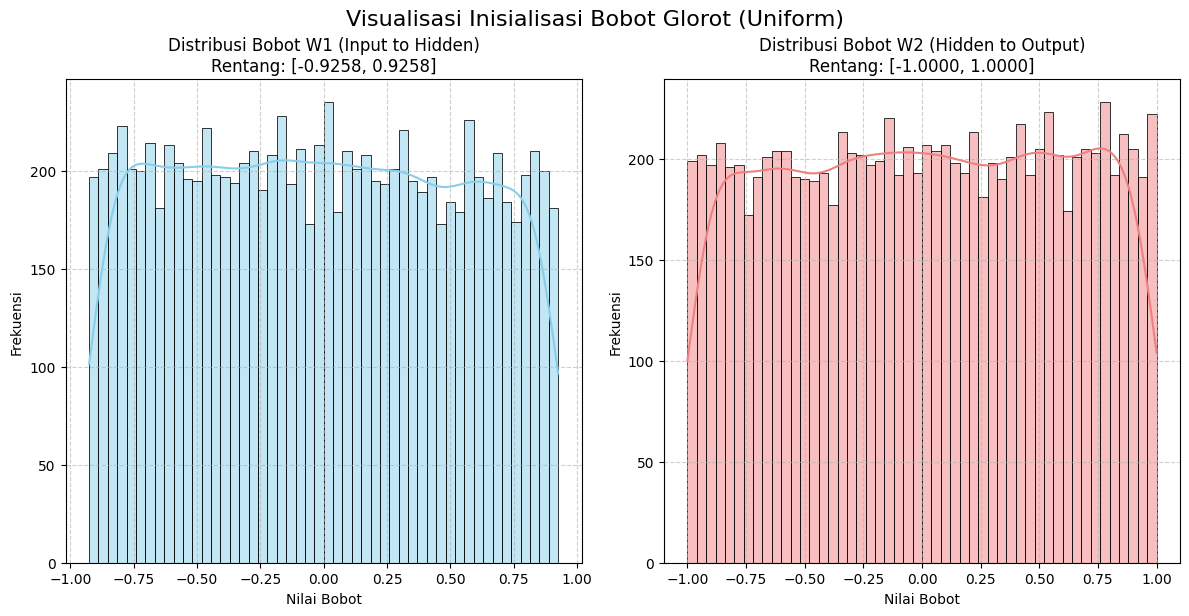


Distribusi Bias B1 dan B2:
Bias B1 (Hidden Layer): Semua nilai 0.0
Bias B2 (Output Layer): Semua nilai 0.0


In [15]:
# prompt: visualisasikan inisialisasi bobot Glorot

import matplotlib.pyplot as plt
import numpy as np
# Fungsi untuk memvisualisasikan distribusi bobot Glorot
def visualize_glorot_initialization(input_dim, hidden_neurons):
    """Memvisualisasikan distribusi bobot yang dihasilkan oleh inisialisasi Glorot."""
    # Ambil rentang Glorot dari fungsi glorot_init (tanpa membuat instance penuh)
    limit_w1 = np.sqrt(6 / (input_dim + hidden_neurons))
    limit_w2 = np.sqrt(6 / (hidden_neurons + 1))

    # Hasilkan sampel bobot dalam jumlah besar dari rentang Glorot
    num_samples = 10000  # Ambil sampel dalam jumlah besar untuk visualisasi distribusi
    w1_samples = np.random.uniform(-limit_w1, limit_w1, size=num_samples)
    w2_samples = np.random.uniform(-limit_w2, limit_w2, size=num_samples)
    b1_samples = np.zeros(num_samples) # Bias biasanya 0 atau kecil
    b2_samples = np.zeros(num_samples)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    sns.histplot(w1_samples, kde=True, color='skyblue', bins=50)
    plt.title(f'Distribusi Bobot W1 (Input to Hidden)\nRentang: [{-limit_w1:.4f}, {limit_w1:.4f}]')
    plt.xlabel('Nilai Bobot')
    plt.ylabel('Frekuensi')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 2, 2)
    sns.histplot(w2_samples, kde=True, color='lightcoral', bins=50)
    plt.title(f'Distribusi Bobot W2 (Hidden to Output)\nRentang: [{-limit_w2:.4f}, {limit_w2:.4f}]')
    plt.xlabel('Nilai Bobot')
    plt.ylabel('Frekuensi')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.suptitle(f'Visualisasi Inisialisasi Bobot Glorot (Uniform)', y=1.02, fontsize=16)
    plt.savefig(f'docs/glorot_initialization_distribution.png')
    plt.show()

    print("\nDistribusi Bias B1 dan B2:")
    print(f"Bias B1 (Hidden Layer): Semua nilai 0.0")
    print(f"Bias B2 (Output Layer): Semua nilai 0.0")


# Visualisasikan inisialisasi bobot Glorot menggunakan parameter yang sudah didefinisikan
visualize_glorot_initialization(INPUT_DIM, HIDDEN_NEURONS)


## 7. Setup Algoritma Genetika
Mendefinisikan komponen GA untuk optimasi bobot ANN.

In [ ]:
# Setup DEAP untuk GA
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_float", glorot_init, INPUT_DIM, HIDDEN_NEURONS)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.attr_float)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=MUTATION_SIGMA, indpb=0.1)

if SELECTION_METHOD == "rws":
    toolbox.register("select", tools.selRoulette)
else:
    toolbox.register("select", tools.selTournament, tournsize=TOURNAMENT_SIZE)

## 8. Pelatihan GANN per Fold
Melatih model GANN menggunakan GA untuk optimasi bobot pada setiap *fold*.


=== Melatih GANN Fold 1 ===
Generasi 1: Rata-rata Fitness (1/RMSE) = 3.505994, Maksimum Fitness (1/RMSE) = 10.685870
Generasi 2: Rata-rata Fitness (1/RMSE) = 4.502751, Maksimum Fitness (1/RMSE) = 10.685870
Generasi 3: Rata-rata Fitness (1/RMSE) = 6.323993, Maksimum Fitness (1/RMSE) = 11.206878
Generasi 4: Rata-rata Fitness (1/RMSE) = 7.332462, Maksimum Fitness (1/RMSE) = 11.206878
Generasi 5: Rata-rata Fitness (1/RMSE) = 8.541284, Maksimum Fitness (1/RMSE) = 11.206878
Generasi 6: Rata-rata Fitness (1/RMSE) = 9.155962, Maksimum Fitness (1/RMSE) = 11.206878
Generasi 7: Rata-rata Fitness (1/RMSE) = 9.729096, Maksimum Fitness (1/RMSE) = 11.206878
Generasi 8: Rata-rata Fitness (1/RMSE) = 10.111441, Maksimum Fitness (1/RMSE) = 11.206878
Generasi 9: Rata-rata Fitness (1/RMSE) = 10.109976, Maksimum Fitness (1/RMSE) = 11.206878
Generasi 10: Rata-rata Fitness (1/RMSE) = 10.023552, Maksimum Fitness (1/RMSE) = 11.206878
Generasi 11: Rata-rata Fitness (1/RMSE) = 10.555017, Maksimum Fitness (1/RMSE

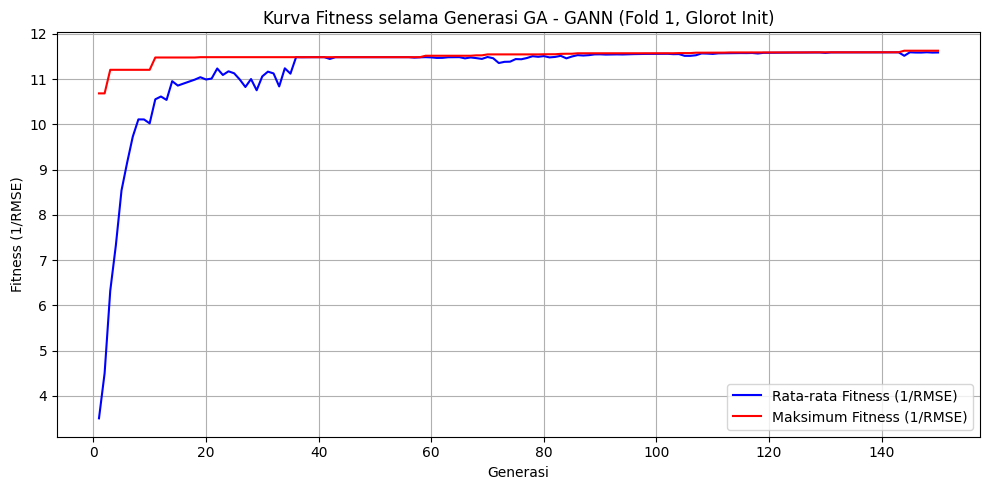


=== Melatih GANN Fold 2 ===
Generasi 1: Rata-rata Fitness (1/RMSE) = 3.610122, Maksimum Fitness (1/RMSE) = 12.177414
Generasi 2: Rata-rata Fitness (1/RMSE) = 5.182512, Maksimum Fitness (1/RMSE) = 12.845222
Generasi 3: Rata-rata Fitness (1/RMSE) = 6.761163, Maksimum Fitness (1/RMSE) = 12.845222
Generasi 4: Rata-rata Fitness (1/RMSE) = 8.166379, Maksimum Fitness (1/RMSE) = 13.426300
Generasi 5: Rata-rata Fitness (1/RMSE) = 9.256910, Maksimum Fitness (1/RMSE) = 13.426300
Generasi 6: Rata-rata Fitness (1/RMSE) = 10.116040, Maksimum Fitness (1/RMSE) = 13.426300
Generasi 7: Rata-rata Fitness (1/RMSE) = 10.777507, Maksimum Fitness (1/RMSE) = 13.426300
Generasi 8: Rata-rata Fitness (1/RMSE) = 11.256315, Maksimum Fitness (1/RMSE) = 13.426300
Generasi 9: Rata-rata Fitness (1/RMSE) = 11.962993, Maksimum Fitness (1/RMSE) = 13.561709
Generasi 10: Rata-rata Fitness (1/RMSE) = 12.354777, Maksimum Fitness (1/RMSE) = 13.561709
Generasi 11: Rata-rata Fitness (1/RMSE) = 12.585620, Maksimum Fitness (1/RM

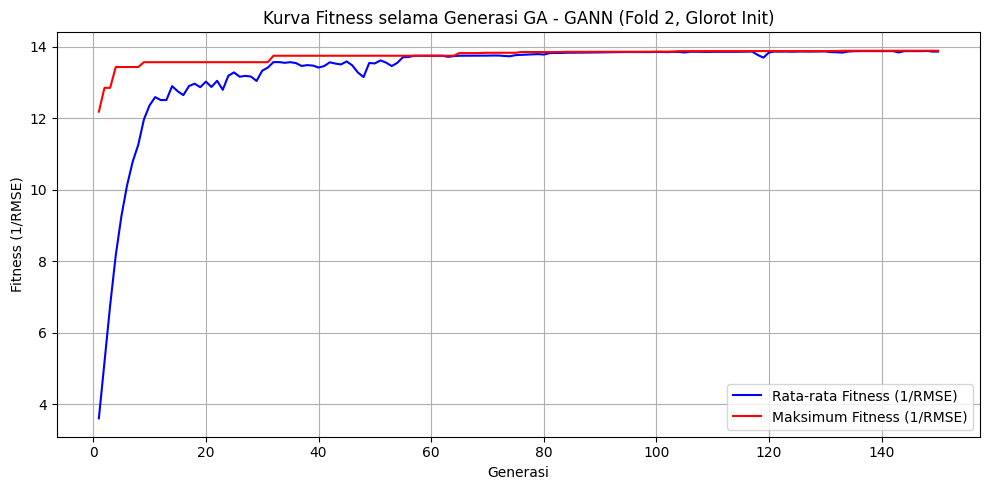


=== Melatih GANN Fold 3 ===
Generasi 1: Rata-rata Fitness (1/RMSE) = 5.062827, Maksimum Fitness (1/RMSE) = 14.919762
Generasi 2: Rata-rata Fitness (1/RMSE) = 7.606495, Maksimum Fitness (1/RMSE) = 14.919762
Generasi 3: Rata-rata Fitness (1/RMSE) = 9.793105, Maksimum Fitness (1/RMSE) = 14.919762
Generasi 4: Rata-rata Fitness (1/RMSE) = 11.662773, Maksimum Fitness (1/RMSE) = 15.021779
Generasi 5: Rata-rata Fitness (1/RMSE) = 12.770326, Maksimum Fitness (1/RMSE) = 15.021779
Generasi 6: Rata-rata Fitness (1/RMSE) = 13.739731, Maksimum Fitness (1/RMSE) = 15.021779
Generasi 7: Rata-rata Fitness (1/RMSE) = 13.606411, Maksimum Fitness (1/RMSE) = 15.021779
Generasi 8: Rata-rata Fitness (1/RMSE) = 13.940181, Maksimum Fitness (1/RMSE) = 15.021779
Generasi 9: Rata-rata Fitness (1/RMSE) = 14.257791, Maksimum Fitness (1/RMSE) = 15.021779
Generasi 10: Rata-rata Fitness (1/RMSE) = 14.255991, Maksimum Fitness (1/RMSE) = 15.021779
Generasi 11: Rata-rata Fitness (1/RMSE) = 14.157663, Maksimum Fitness (1/

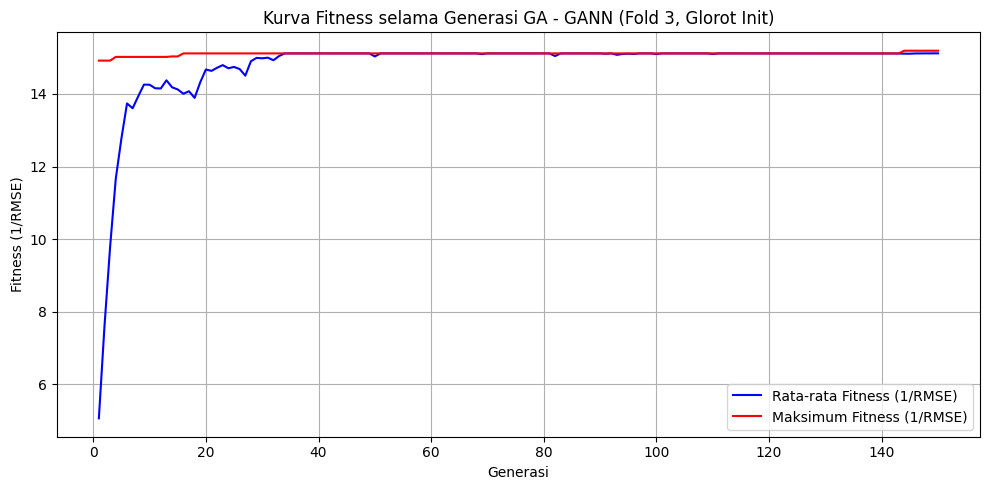


=== Melatih GANN Fold 4 ===
Generasi 1: Rata-rata Fitness (1/RMSE) = 4.999821, Maksimum Fitness (1/RMSE) = 16.739106
Generasi 2: Rata-rata Fitness (1/RMSE) = 6.596193, Maksimum Fitness (1/RMSE) = 16.739106
Generasi 3: Rata-rata Fitness (1/RMSE) = 8.704078, Maksimum Fitness (1/RMSE) = 16.739106
Generasi 4: Rata-rata Fitness (1/RMSE) = 10.371450, Maksimum Fitness (1/RMSE) = 16.739106
Generasi 5: Rata-rata Fitness (1/RMSE) = 12.576532, Maksimum Fitness (1/RMSE) = 16.739106
Generasi 6: Rata-rata Fitness (1/RMSE) = 13.520617, Maksimum Fitness (1/RMSE) = 16.739106
Generasi 7: Rata-rata Fitness (1/RMSE) = 14.130963, Maksimum Fitness (1/RMSE) = 16.739106
Generasi 8: Rata-rata Fitness (1/RMSE) = 14.906073, Maksimum Fitness (1/RMSE) = 16.739106
Generasi 9: Rata-rata Fitness (1/RMSE) = 15.572788, Maksimum Fitness (1/RMSE) = 16.739106
Generasi 10: Rata-rata Fitness (1/RMSE) = 16.232249, Maksimum Fitness (1/RMSE) = 16.739106
Generasi 11: Rata-rata Fitness (1/RMSE) = 15.658086, Maksimum Fitness (1/

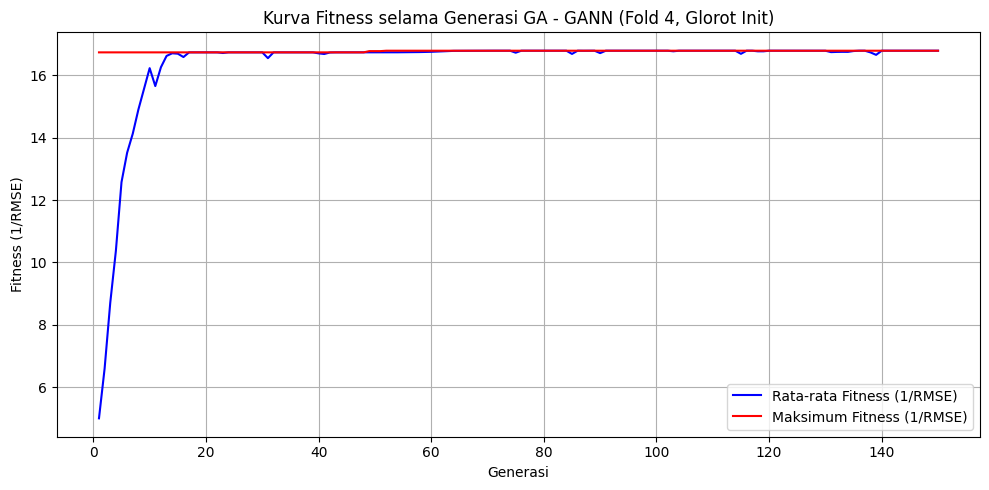

In [ ]:
# Inisialisasi untuk menyimpan hasil
gann_metrics = []
gann_predictions_per_fold = []
gann_best_weights = []
gann_history = []

# Parameter elitisme
ELITE_SIZE = int(POPULATION_SIZE * 0.6)  # N-2d, misalnya 60% dari populasi (N=100, 2d=40)

# Loop untuk setiap fold
for data in fold_data:
    fold = data['fold']
    X_train = data['X_train']
    y_train = data['y_train']
    X_test = data['X_test']
    y_test = data['y_test']
    train_close = data['train_close']
    test_close = data['test_close']
    train_dates = data['train_dates']
    test_dates = data['test_dates']
    close_min = data['close_min']
    close_max = data['close_max']

    print(f"\n=== Melatih GANN Fold {fold} ===")

    # Buat model untuk GA
    gann_model = build_ann_model(INPUT_DIM, HIDDEN_NEURONS, use_dropout=False, use_l2=False)

    # Register fungsi evaluasi
    toolbox.register("evaluate", evaluate_individual, model=gann_model, X=X_train, y=y_train)

    # Jalankan GA
    population = toolbox.population(n=POPULATION_SIZE)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("max", np.max)
    hof = tools.HallOfFame(1)

    fitness_avg_history = []
    fitness_max_history = []

    # Evaluasi fitness untuk populasi awal
    fitnesses = toolbox.map(toolbox.evaluate, population)
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit
    hof.update(population)

    for gen in range(GENERATIONS):
        # Simpan populasi sebelumnya untuk elitisme
        prev_population = population[:]
        # Hasilkan keturunan baru
        offspring = algorithms.varAnd(population, toolbox, cxpb=CROSSOVER_PROB, mutpb=MUTATION_PROB)
        # Evaluasi fitness untuk individu baru
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit
        # Perbarui Hall of Fame
        hof.update(offspring)
        # Pilih individu terbaik dari populasi sebelumnya
        prev_population = sorted(prev_population, key=lambda ind: ind.fitness.values[0], reverse=True)
        elite = prev_population[:ELITE_SIZE]  # Ambil N-2d individu terbaik
        # Pilih 2d individu dari keturunan
        selected = toolbox.select(offspring, POPULATION_SIZE - ELITE_SIZE)
        # Bentuk populasi baru
        population = elite + selected
        record = stats.compile(population)
        fitness_avg_history.append(record['avg'])
        fitness_max_history.append(record['max'])
        print(f"Generasi {gen + 1}: Rata-rata Fitness (1/RMSE) = {record['avg']:.6f}, Maksimum Fitness (1/RMSE) = {record['max']:.6f}")

    # Visualisasi kurva fitness
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, GENERATIONS + 1), fitness_avg_history, label='Rata-rata Fitness (1/RMSE)', color='blue')
    plt.plot(range(1, GENERATIONS + 1), fitness_max_history, label='Maksimum Fitness (1/RMSE)', color='red')
    plt.title(f'Kurva Fitness selama Generasi GA - GANN (Fold {fold}, Glorot Init)')
    plt.xlabel('Generasi')
    plt.ylabel('Fitness (1/RMSE)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'docs/ihsg_fitness_curve_gann_fold_{fold}_glorot.png')
    plt.show()

    best_weights = hof[0]
    gann_best_weights.append(best_weights)

    # Set bobot terbaik
    set_model_weights(gann_model, best_weights)

    # Prediksi
    gann_predictions = gann_model.predict(np.concatenate([X_train, X_test]), verbose=0).flatten()
    gann_predictions_denorm = denormalize_data(gann_predictions, close_min, close_max)

    # Simpan model
    gann_model.save(f'models/gann_fold_{fold}.keras')

    # Simpan prediksi
    fold_pred_df = pd.DataFrame({
        'Fold': fold,
        'Date': np.concatenate([train_dates[WINDOW_SIZE:], test_dates[WINDOW_SIZE:]]),
        'Actual_Close': np.concatenate([train_close[WINDOW_SIZE:], test_close[WINDOW_SIZE:]]),
        'Predicted_GANN': gann_predictions_denorm,
        'Data': ['Latih'] * len(train_dates[WINDOW_SIZE:]) + ['Uji'] * len(test_dates[WINDOW_SIZE:])
    })
    gann_predictions_per_fold.append(fold_pred_df)

    # Bersihkan memori
    import gc
    gc.collect()
    tf.keras.backend.clear_session()

## 9. Validasi GANN per Fold
Mengevaluasi performa GANN pada setiap *fold* dan membuat visualisasi.


=== Validasi GANN Fold 1 ===


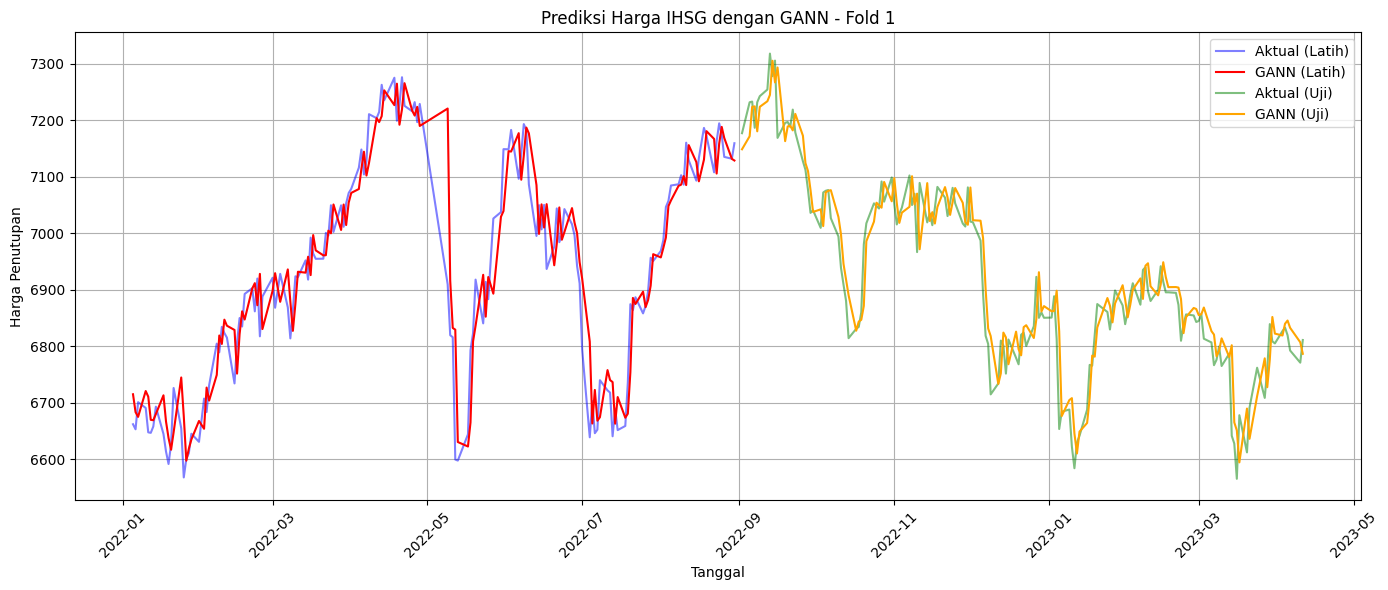


=== Validasi GANN Fold 2 ===


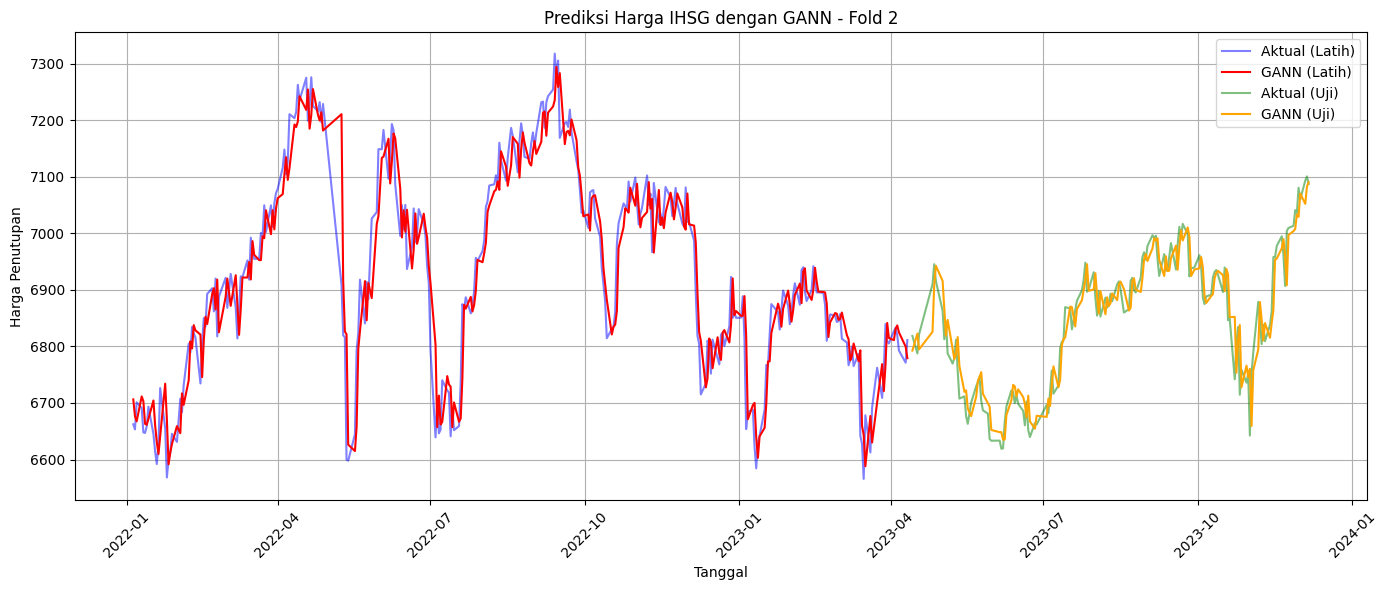


=== Validasi GANN Fold 3 ===


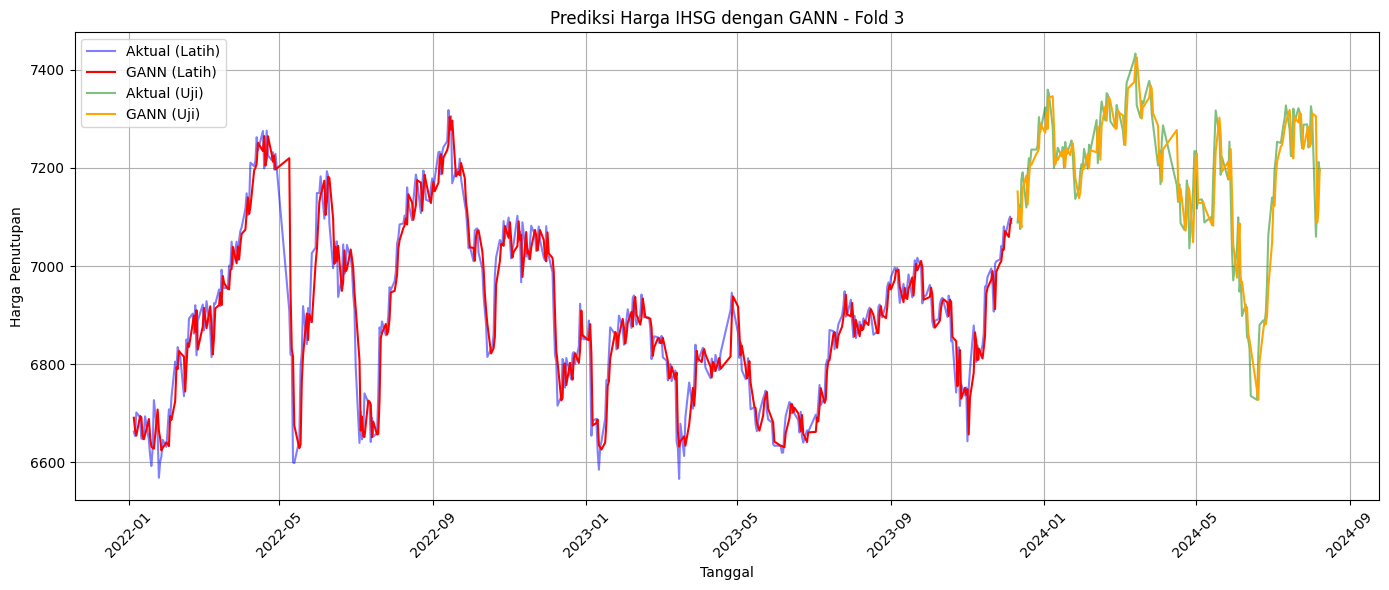


=== Validasi GANN Fold 4 ===


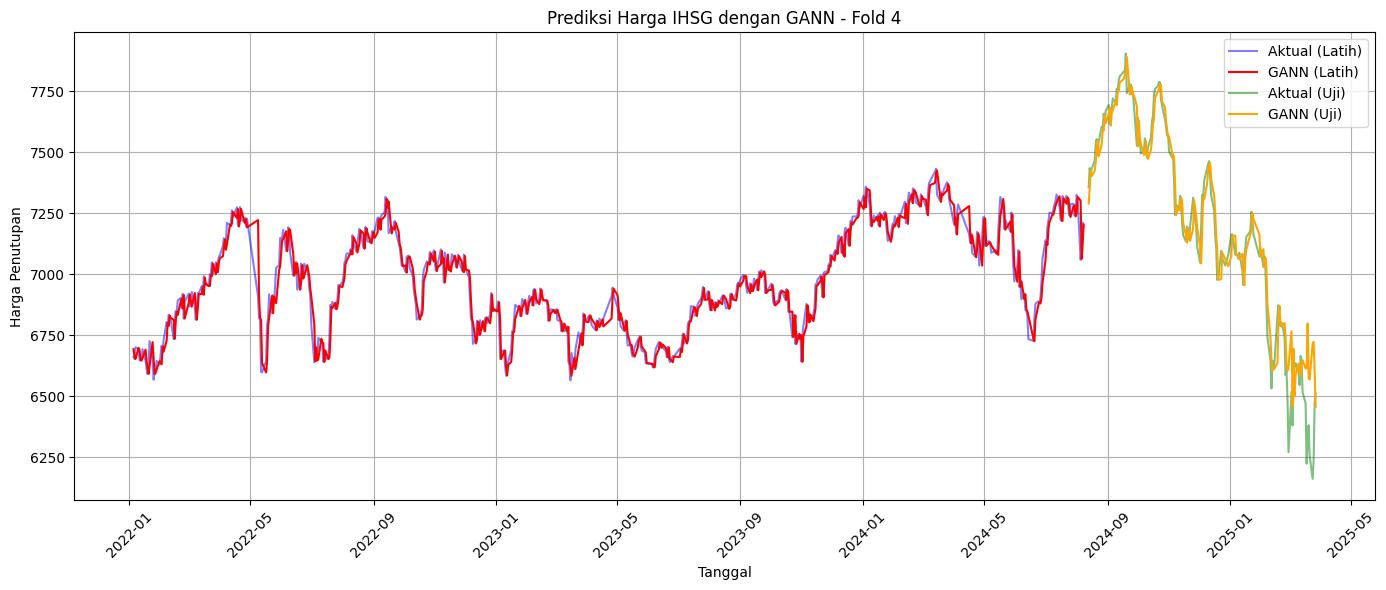

In [ ]:
for data in fold_data:
    fold = data['fold']
    train_close = data['train_close']
    test_close = data['test_close']
    train_dates = data['train_dates']
    test_dates = data['test_dates']

    print(f"\n=== Validasi GANN Fold {fold} ===")

    # Ambil prediksi
    fold_pred_df = gann_predictions_per_fold[fold-1]
    gann_pred = fold_pred_df['Predicted_GANN'].values
    train_pred = gann_pred[:len(train_close[WINDOW_SIZE:])]
    test_pred = gann_pred[len(train_close[WINDOW_SIZE:]):]

    # Hitung metrik
    rmse_train, mae_train, mape_train = calculate_metrics(train_close[WINDOW_SIZE:], train_pred)
    rmse_test, mae_test, mape_test = calculate_metrics(test_close[WINDOW_SIZE:], test_pred)
    gann_metrics.append({'Fold': fold, 'Data': 'Latih', 'RMSE': rmse_train, 'MAE': mae_train, 'MAPE': mape_train})
    gann_metrics.append({'Fold': fold, 'Data': 'Uji', 'RMSE': rmse_test, 'MAE': mae_test, 'MAPE': mape_test})

    # Visualisasi prediksi vs aktual
    plt.figure(figsize=(14, 6))
    plt.plot(train_dates[WINDOW_SIZE:], train_close[WINDOW_SIZE:], label='Aktual (Latih)', color='blue', alpha=0.5)
    plt.plot(train_dates[WINDOW_SIZE:], train_pred, label='GANN (Latih)', color='red')
    plt.plot(test_dates[WINDOW_SIZE:], test_close[WINDOW_SIZE:], label='Aktual (Uji)', color='green', alpha=0.5)
    plt.plot(test_dates[WINDOW_SIZE:], test_pred, label='GANN (Uji)', color='orange')
    plt.title(f'Prediksi Harga IHSG dengan GANN - Fold {fold}')
    plt.xlabel('Tanggal')
    plt.ylabel('Harga Penutupan')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'docs/ihsg_prediction_gann_fold_{fold}_glorot.png')
    plt.show()

## 10. Pelatihan GADAM per Fold
Melatih model GADAM dengan inisialisasi bobot dari GANN, diikuti pelatihan dengan optimizer ADAM.

In [ ]:
# Inisialisasi untuk menyimpan hasil
gadam_metrics = []
gadam_predictions_per_fold = []
gadam_history = []

# Loop untuk setiap fold
for data in fold_data:
    fold = data['fold']
    X_train = data['X_train']
    y_train = data['y_train']
    X_test = data['X_test']
    y_test = data['y_test']
    train_close = data['train_close']
    test_close = data['test_close']
    train_dates = data['train_dates']
    test_dates = data['test_dates']
    close_min = data['close_min']
    close_max = data['close_max']

    print(f"\n=== Melatih GADAM Fold {fold} ===")

    # Buat model GADAM dan set bobot awal dari GANN
    gadam_model = build_ann_model(INPUT_DIM, HIDDEN_NEURONS, use_dropout=False, use_l2=False)
    set_model_weights(gadam_model, gann_best_weights[fold-1])

    # Latih dengan ADAM
    history = gadam_model.fit(X_train, y_train,
                              epochs=EPOCHS,
                              batch_size=BATCH_SIZE,
                              validation_data=(X_test, y_test),
                              verbose=0,
                              callbacks=[EpochLogger(fold, 'GADAM'),
                                         tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=EARLY_STOP_PATIENCE, verbose=1),
                                         LearningRateScheduler(lr_scheduler)])
    gadam_history.append(history.history)

    # Prediksi
    gadam_predictions = gadam_model.predict(np.concatenate([X_train, X_test]), verbose=0).flatten()
    gadam_predictions_denorm = denormalize_data(gadam_predictions, close_min, close_max)

    # Simpan model
    gadam_model.save(f'models/gadam_fold_{fold}.keras')

    # Simpan prediksi
    fold_pred_df = pd.DataFrame({
        'Fold': fold,
        'Date': np.concatenate([train_dates[WINDOW_SIZE:], test_dates[WINDOW_SIZE:]]),
        'Actual_Close': np.concatenate([train_close[WINDOW_SIZE:], test_close[WINDOW_SIZE:]]),
        'Predicted_GADAM': gadam_predictions_denorm,
        'Data': ['Latih'] * len(train_dates[WINDOW_SIZE:]) + ['Uji'] * len(test_dates[WINDOW_SIZE:])
    })
    gadam_predictions_per_fold.append(fold_pred_df)

    # Bersihkan memori
    import gc
    gc.collect()
    tf.keras.backend.clear_session()


=== Melatih GADAM Fold 1 ===
Fold 1 - GADAM - Epoch 1: Loss Latih = 0.007388, Loss Validasi = 0.004453
Fold 1 - GADAM - Epoch 2: Loss Latih = 0.007342, Loss Validasi = 0.004406
Fold 1 - GADAM - Epoch 3: Loss Latih = 0.007393, Loss Validasi = 0.004421
Fold 1 - GADAM - Epoch 4: Loss Latih = 0.007376, Loss Validasi = 0.004460
Fold 1 - GADAM - Epoch 5: Loss Latih = 0.007357, Loss Validasi = 0.004466
Fold 1 - GADAM - Epoch 6: Loss Latih = 0.007343, Loss Validasi = 0.004441
Fold 1 - GADAM - Epoch 7: Loss Latih = 0.007342, Loss Validasi = 0.004424
Epoch 7: early stopping

=== Melatih GADAM Fold 2 ===
Fold 2 - GADAM - Epoch 1: Loss Latih = 0.005311, Loss Validasi = 0.002526
Fold 2 - GADAM - Epoch 2: Loss Latih = 0.005213, Loss Validasi = 0.002591
Fold 2 - GADAM - Epoch 3: Loss Latih = 0.005269, Loss Validasi = 0.002513
Fold 2 - GADAM - Epoch 4: Loss Latih = 0.005197, Loss Validasi = 0.002517
Fold 2 - GADAM - Epoch 5: Loss Latih = 0.005194, Loss Validasi = 0.002527
Fold 2 - GADAM - Epoch 6: Lo

## 11. Validasi GADAM per Fold
Mengevaluasi performa GADAM pada setiap *fold* dan membuat visualisasi.

In [ ]:
for data in fold_data:
    fold = data['fold']
    train_close = data['train_close']
    test_close = data['test_close']
    train_dates = data['train_dates']
    test_dates = data['test_dates']

    print(f"\n=== Validasi GADAM Fold {fold} ===")

    # Ambil prediksi
    fold_pred_df = gadam_predictions_per_fold[fold-1]
    gadam_pred = fold_pred_df['Predicted_GADAM'].values
    train_pred = gadam_pred[:len(train_close[WINDOW_SIZE:])]
    test_pred = gadam_pred[len(train_close[WINDOW_SIZE:]):]

    # Hitung metrik
    rmse_train, mae_train, mape_train = calculate_metrics(train_close[WINDOW_SIZE:], train_pred)
    rmse_test, mae_test, mape_test = calculate_metrics(test_close[WINDOW_SIZE:], test_pred)
    gadam_metrics.append({'Fold': fold, 'Data': 'Latih', 'RMSE': rmse_train, 'MAE': mae_train, 'MAPE': mape_train})
    gadam_metrics.append({'Fold': fold, 'Data': 'Uji', 'RMSE': rmse_test, 'MAE': mae_test, 'MAPE': mape_test})

    # Visualisasi prediksi vs aktual
    plt.figure(figsize=(14, 6))
    plt.plot(train_dates[WINDOW_SIZE:], train_close[WINDOW_SIZE:], label='Aktual (Latih)', color='blue', alpha=0.5)
    plt.plot(train_dates[WINDOW_SIZE:], train_pred, label='GADAM (Latih)', color='purple')
    plt.plot(test_dates[WINDOW_SIZE:], test_close[WINDOW_SIZE:], label='Aktual (Uji)', color='green', alpha=0.5)
    plt.plot(test_dates[WINDOW_SIZE:], test_pred, label='GADAM (Uji)', color='pink')
    plt.title(f'Prediksi Harga IHSG dengan GADAM - Fold {fold}')
    plt.xlabel('Tanggal')
    plt.ylabel('Harga Penutupan')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'docs/ihsg_prediction_gadam_fold_{fold}_glorot.png')
    plt.show()

    # Visualisasi kurva loss
    history = gadam_history[fold-1]
    plt.figure(figsize=(10, 5))
    plt.plot(history['loss'], label='Loss Latih (GADAM)', color='blue')
    plt.plot(history['val_loss'], label='Loss Uji (GADAM)', color='orange')
    plt.title(f'Kurva Loss Pelatihan - GADAM (Fold {fold}, Glorot Init)')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'docs/ihsg_loss_curve_gadam_fold_{fold}_glorot.png')
    plt.show()

## 12. Pelatihan ADAM per Fold
Melatih model ANN langsung dengan ADAM tanpa optimasi GA.

In [ ]:
# Inisialisasi untuk menyimpan hasil
adam_metrics = []
adam_predictions_per_fold = []
adam_history = []

# Loop untuk setiap fold
for data in fold_data:
    fold = data['fold']
    X_train = data['X_train']
    y_train = data['y_train']
    X_test = data['X_test']
    y_test = data['y_test']
    train_close = data['train_close']
    test_close = data['test_close']
    train_dates = data['train_dates']
    test_dates = data['test_dates']
    close_min = data['close_min']
    close_max = data['close_max']

    print(f"\n=== Melatih ADAM Fold {fold} ===")

    # Buat model ADAM
    adam_model = build_ann_model(INPUT_DIM, HIDDEN_NEURONS, use_dropout=True, use_l2=True)

    # Latih dengan ADAM
    history = adam_model.fit(X_train, y_train,
                             epochs=EPOCHS,
                             batch_size=BATCH_SIZE,
                             validation_data=(X_test, y_test),
                             verbose=0,
                             callbacks=[EpochLogger(fold, 'ADAM'),
                                        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=EARLY_STOP_PATIENCE, verbose=1),
                                        LearningRateScheduler(lr_scheduler)])
    adam_history.append(history.history)

    # Prediksi
    adam_predictions = adam_model.predict(np.concatenate([X_train, X_test]), verbose=0).flatten()
    adam_predictions_denorm = denormalize_data(adam_predictions, close_min, close_max)

    # Simpan model
    adam_model.save(f'models/adam_fold_{fold}.keras')

    # Simpan prediksi
    fold_pred_df = pd.DataFrame({
        'Fold': fold,
        'Date': np.concatenate([train_dates[WINDOW_SIZE:], test_dates[WINDOW_SIZE:]]),
        'Actual_Close': np.concatenate([train_close[WINDOW_SIZE:], test_close[WINDOW_SIZE:]]),
        'Predicted_ADAM': adam_predictions_denorm,
        'Data': ['Latih'] * len(train_dates[WINDOW_SIZE:]) + ['Uji'] * len(test_dates[WINDOW_SIZE:])
    })
    adam_predictions_per_fold.append(fold_pred_df)

    # Bersihkan memori
    import gc
    gc.collect()
    tf.keras.backend.clear_session()

## 13. Validasi ADAM per Fold
Mengevaluasi performa ADAM pada setiap *fold* dan membuat visualisasi.


=== Validasi ADAM Fold 1 ===


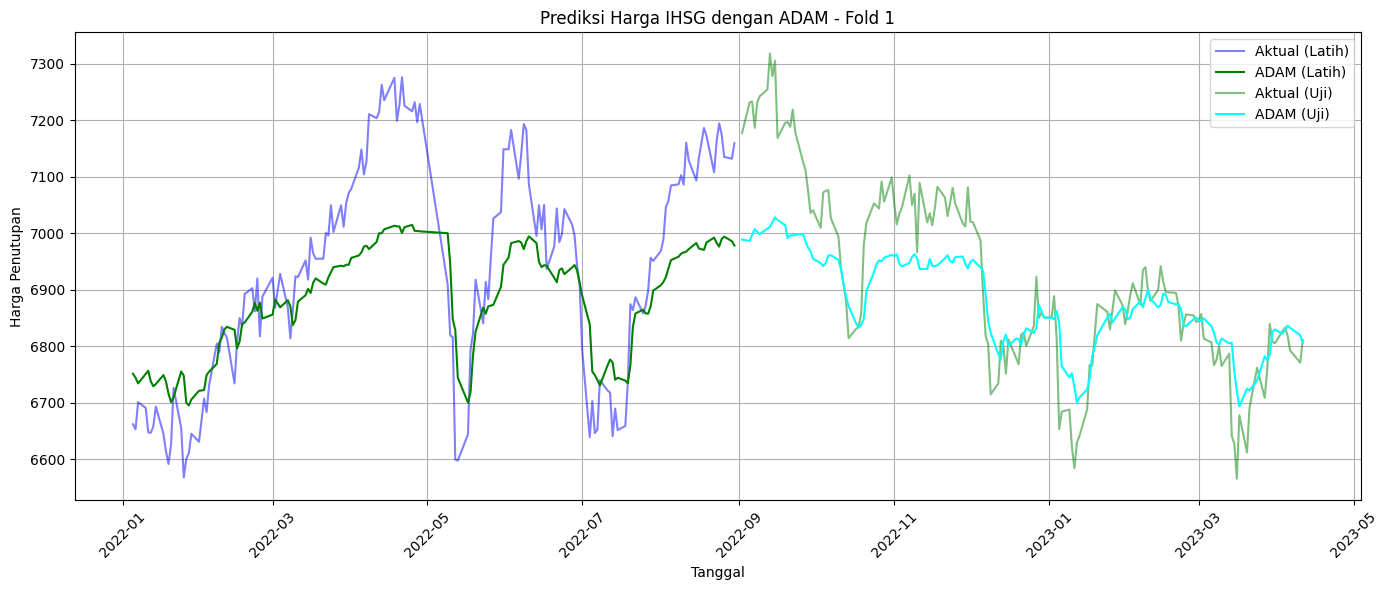

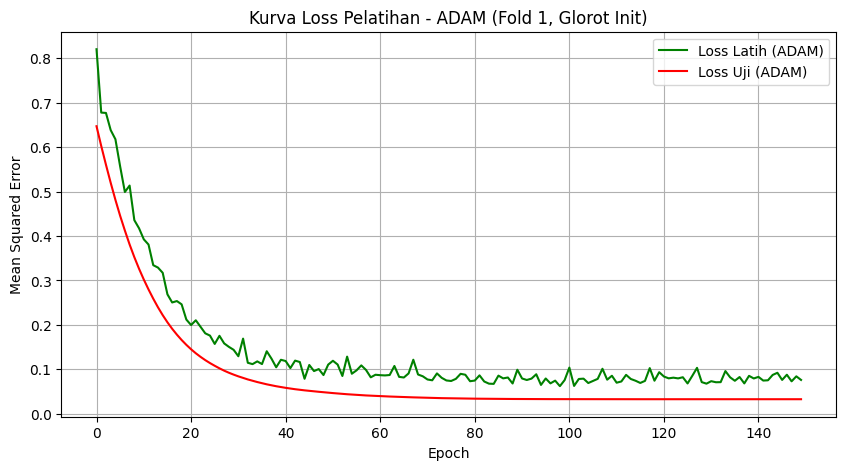


=== Validasi ADAM Fold 2 ===


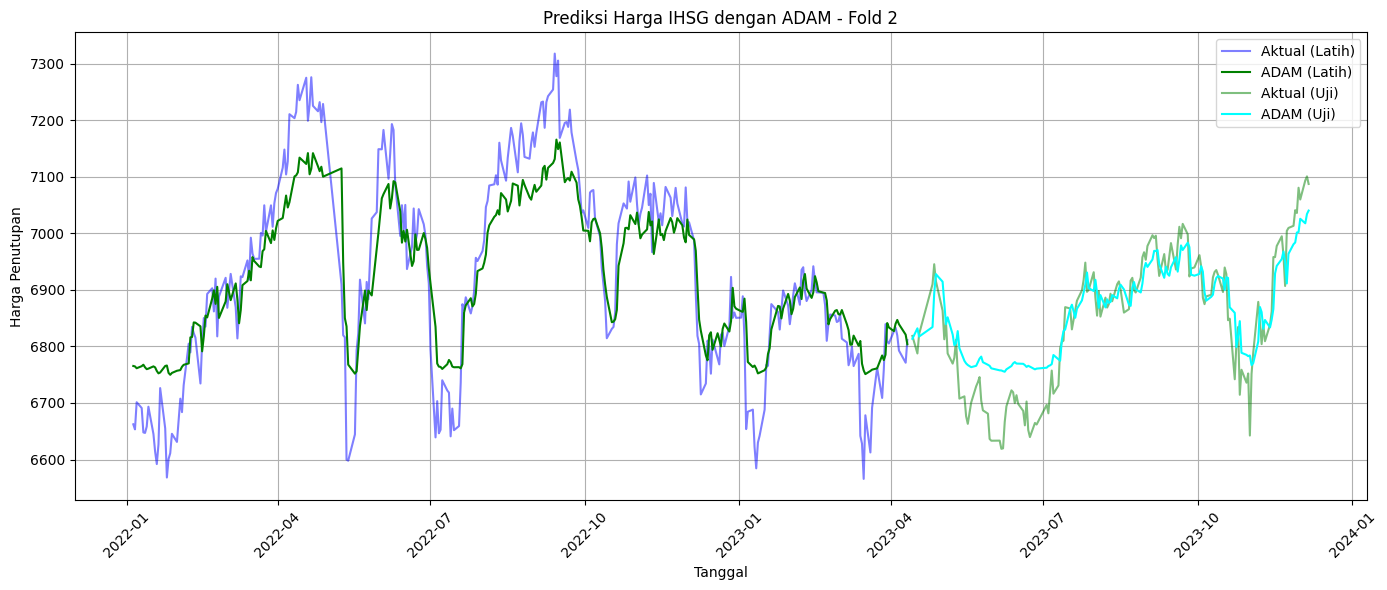

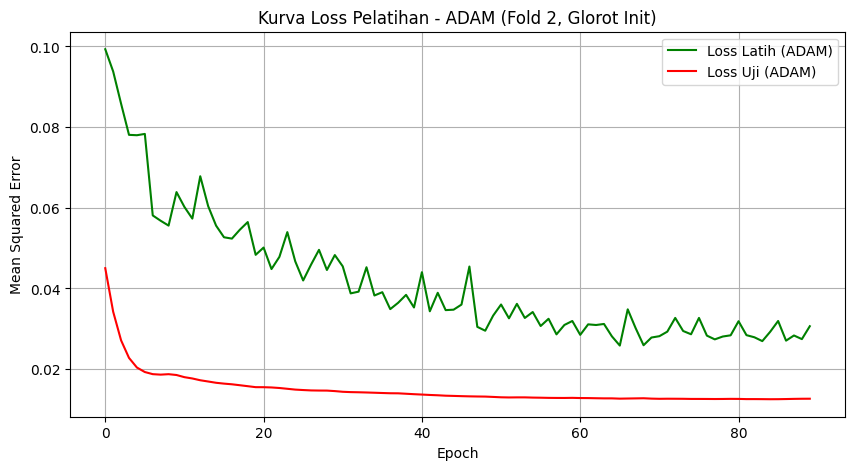


=== Validasi ADAM Fold 3 ===


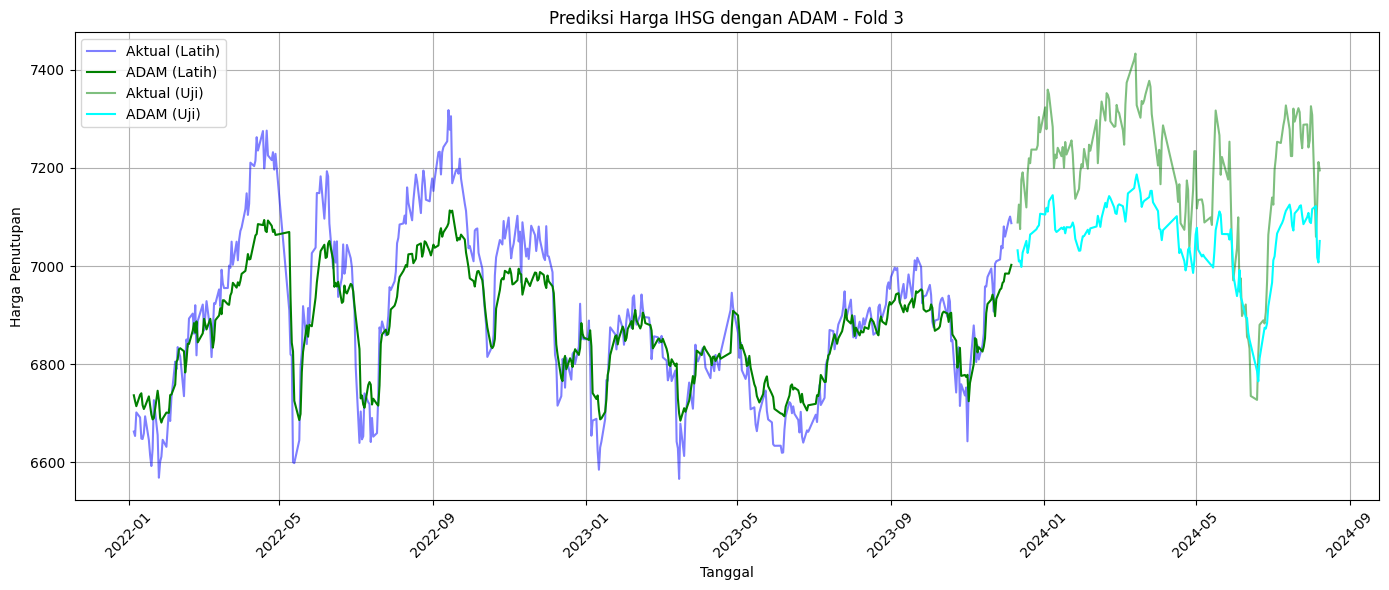

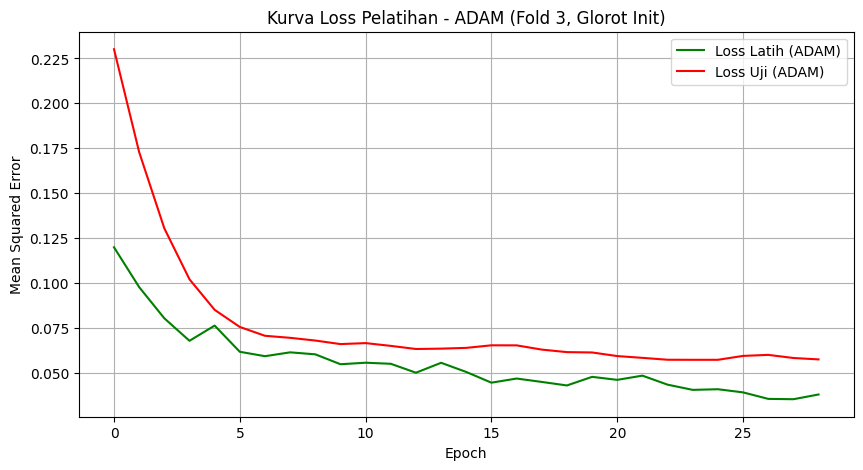


=== Validasi ADAM Fold 4 ===


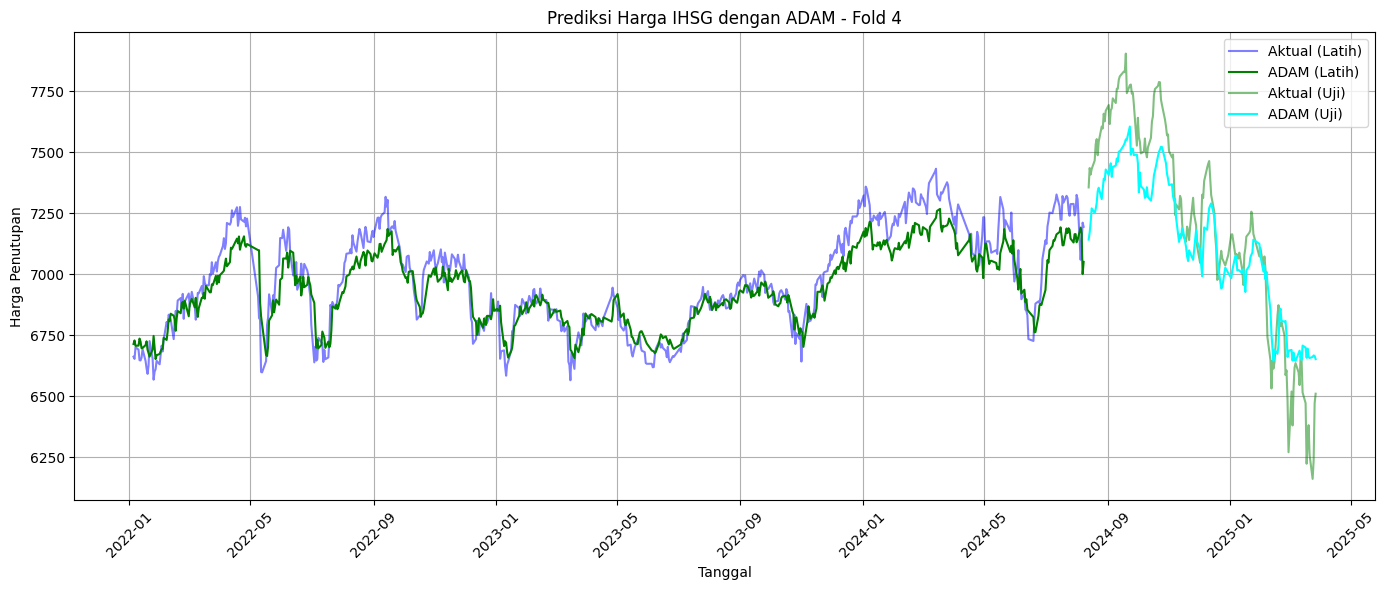

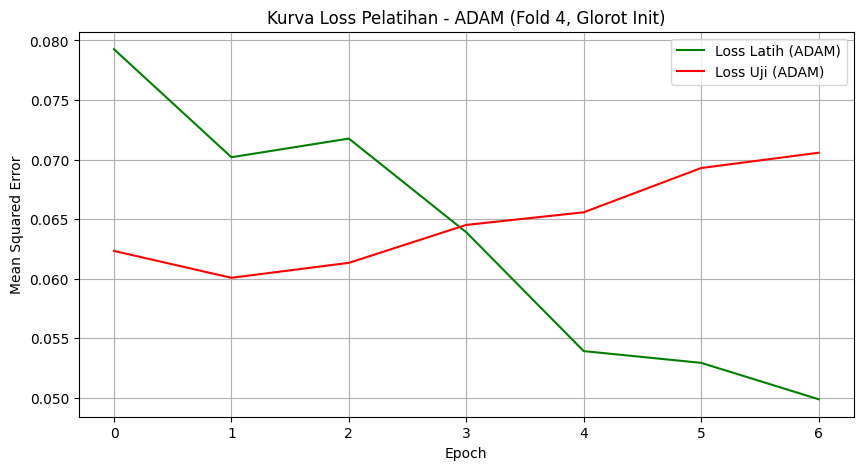

In [ ]:
for data in fold_data:
    fold = data['fold']
    train_close = data['train_close']
    test_close = data['test_close']
    train_dates = data['train_dates']
    test_dates = data['test_dates']

    print(f"\n=== Validasi ADAM Fold {fold} ===")

    # Ambil prediksi
    fold_pred_df = adam_predictions_per_fold[fold-1]
    adam_pred = fold_pred_df['Predicted_ADAM'].values
    train_pred = adam_pred[:len(train_close[WINDOW_SIZE:])]
    test_pred = adam_pred[len(train_close[WINDOW_SIZE:]):]

    # Hitung metrik
    rmse_train, mae_train, mape_train = calculate_metrics(train_close[WINDOW_SIZE:], train_pred)
    rmse_test, mae_test, mape_test = calculate_metrics(test_close[WINDOW_SIZE:], test_pred)
    adam_metrics.append({'Fold': fold, 'Data': 'Latih', 'RMSE': rmse_train, 'MAE': mae_train, 'MAPE': mape_train})
    adam_metrics.append({'Fold': fold, 'Data': 'Uji', 'RMSE': rmse_test, 'MAE': mae_test, 'MAPE': mape_test})

    # Visualisasi prediksi vs aktual
    plt.figure(figsize=(14, 6))
    plt.plot(train_dates[WINDOW_SIZE:], train_close[WINDOW_SIZE:], label='Aktual (Latih)', color='blue', alpha=0.5)
    plt.plot(train_dates[WINDOW_SIZE:], train_pred, label='ADAM (Latih)', color='green')
    plt.plot(test_dates[WINDOW_SIZE:], test_close[WINDOW_SIZE:], label='Aktual (Uji)', color='green', alpha=0.5)
    plt.plot(test_dates[WINDOW_SIZE:], test_pred, label='ADAM (Uji)', color='cyan')
    plt.title(f'Prediksi Harga IHSG dengan ADAM - Fold {fold}')
    plt.xlabel('Tanggal')
    plt.ylabel('Harga Penutupan')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'docs/ihsg_prediction_adam_fold_{fold}_glorot.png')
    plt.show()

    # Visualisasi kurva loss
    history = adam_history[fold-1]
    plt.figure(figsize=(10, 5))
    plt.plot(history['loss'], label='Loss Latih (ADAM)', color='green')
    plt.plot(history['val_loss'], label='Loss Uji (ADAM)', color='red')
    plt.title(f'Kurva Loss Pelatihan - ADAM (Fold {fold}, Glorot Init)')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'docs/ihsg_loss_curve_adam_fold_{fold}_glorot.png')
    plt.show()

# 14. Agregasi dan Simpan Hasil
Mengagregasi metrik, menyimpan hasil, dan membuat visualisasi kesalahan prediksi.

In [ ]:
os.makedirs('models', exist_ok=True)
os.makedirs('docs', exist_ok=True)

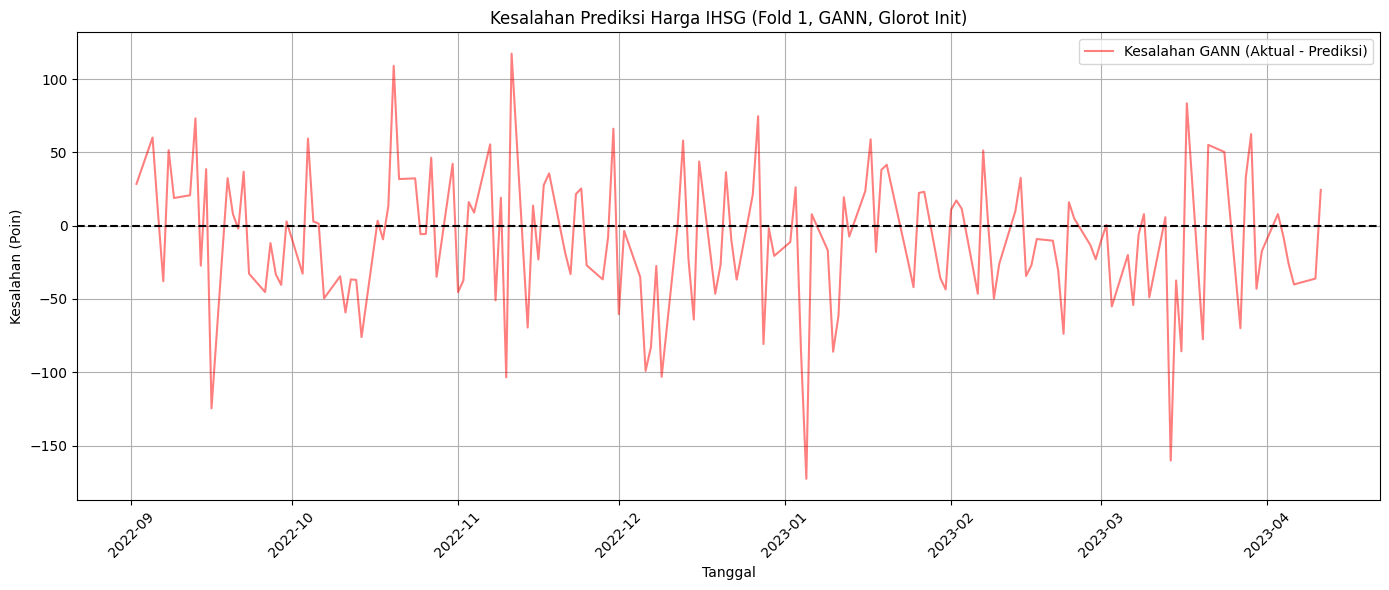

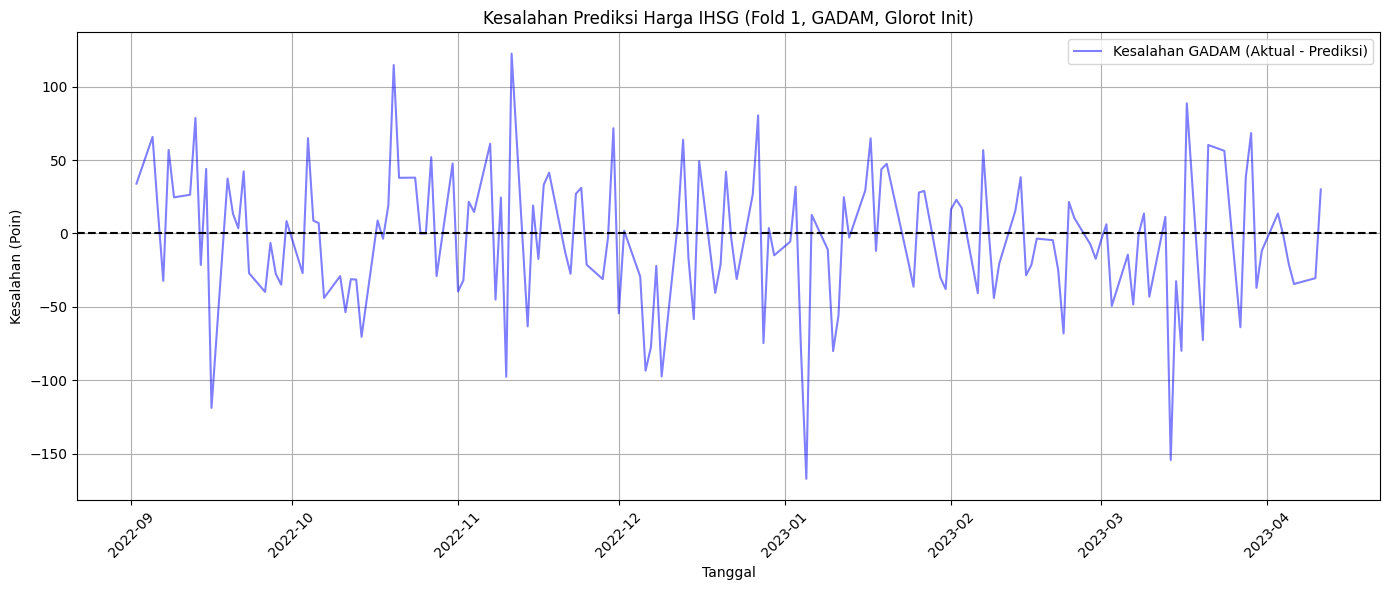

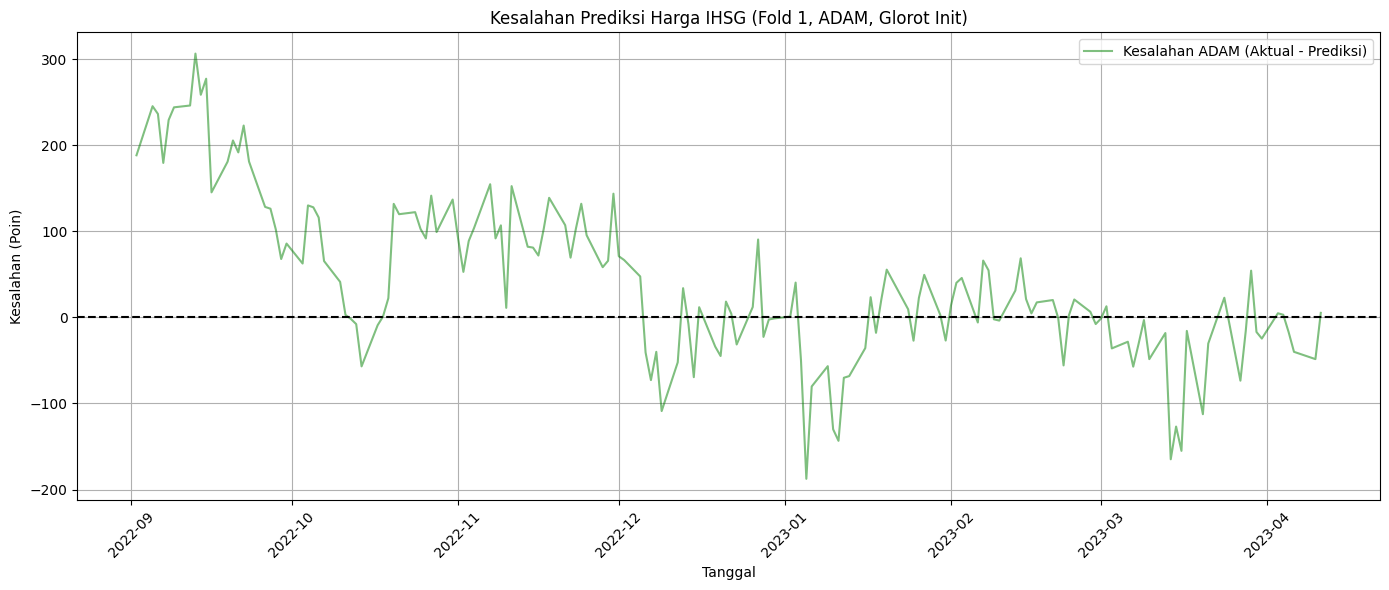

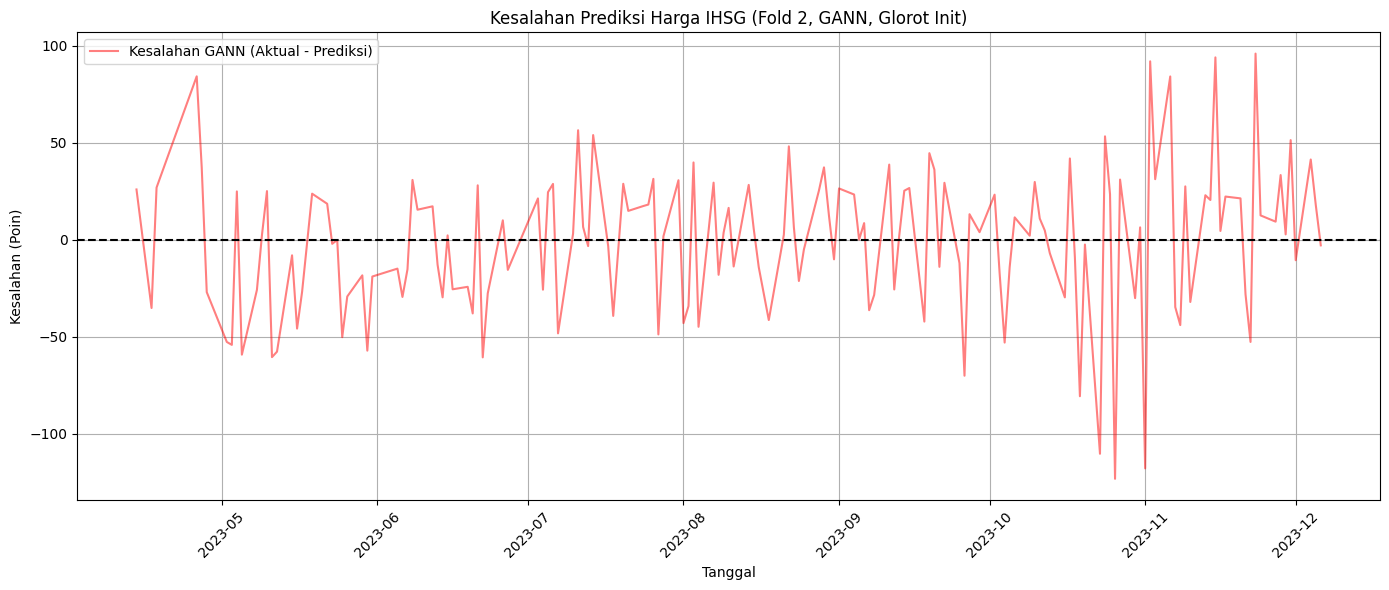

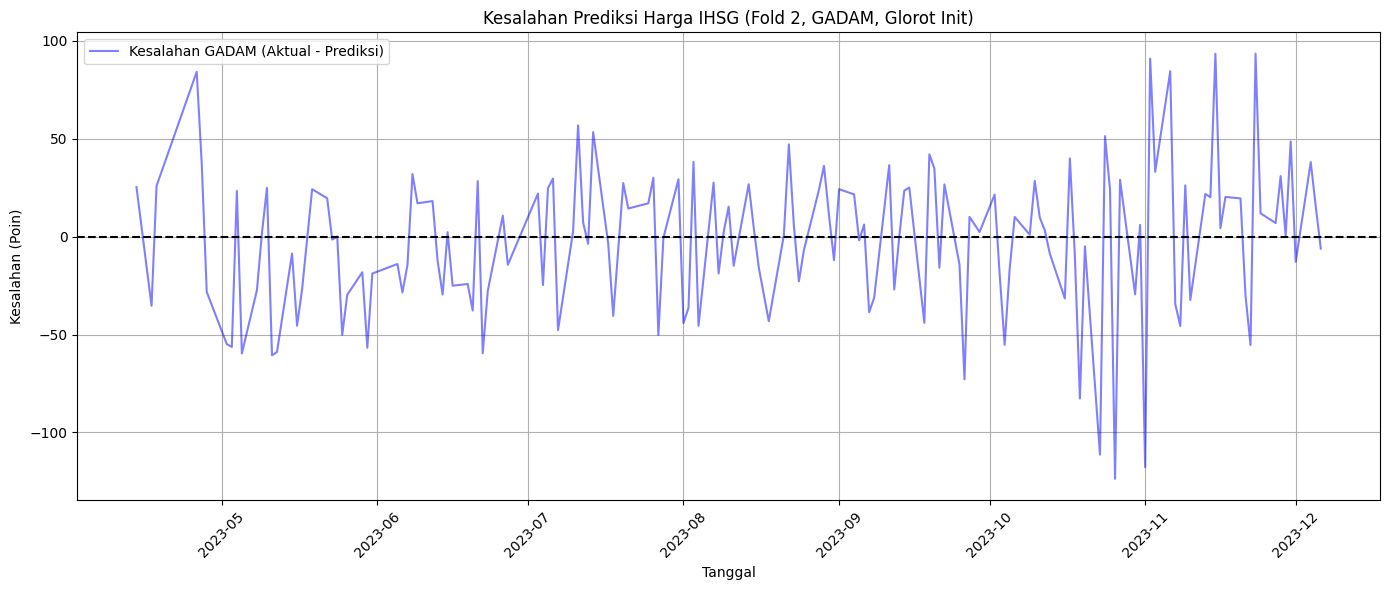

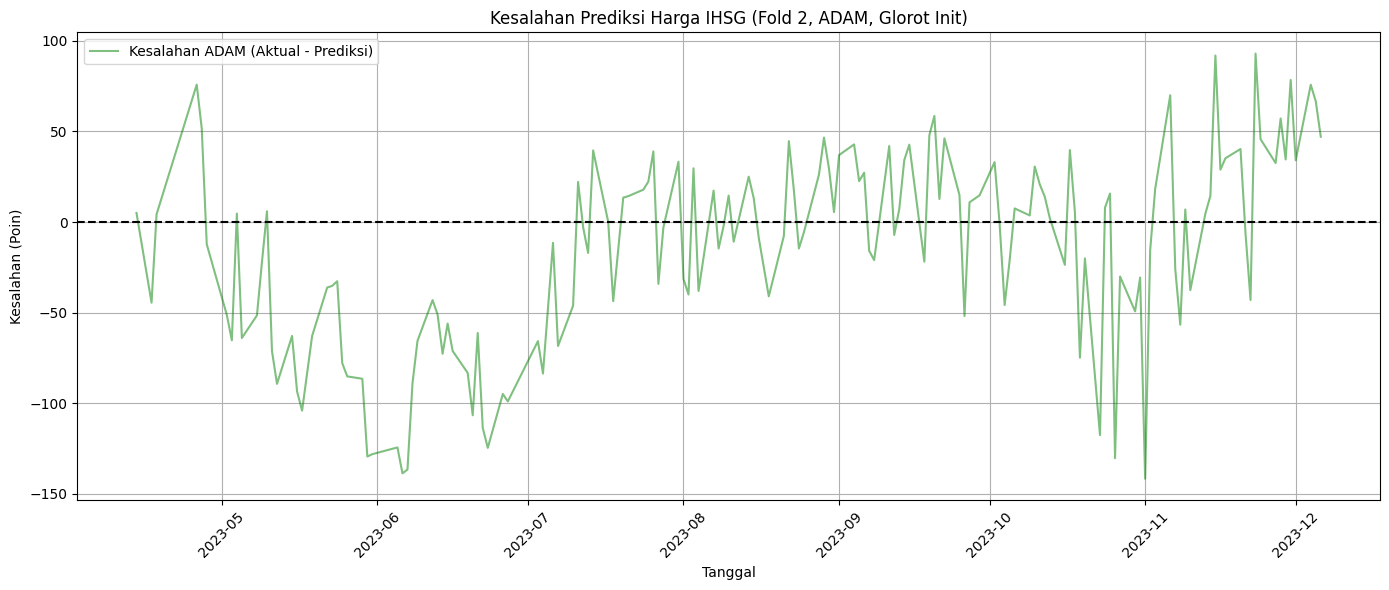

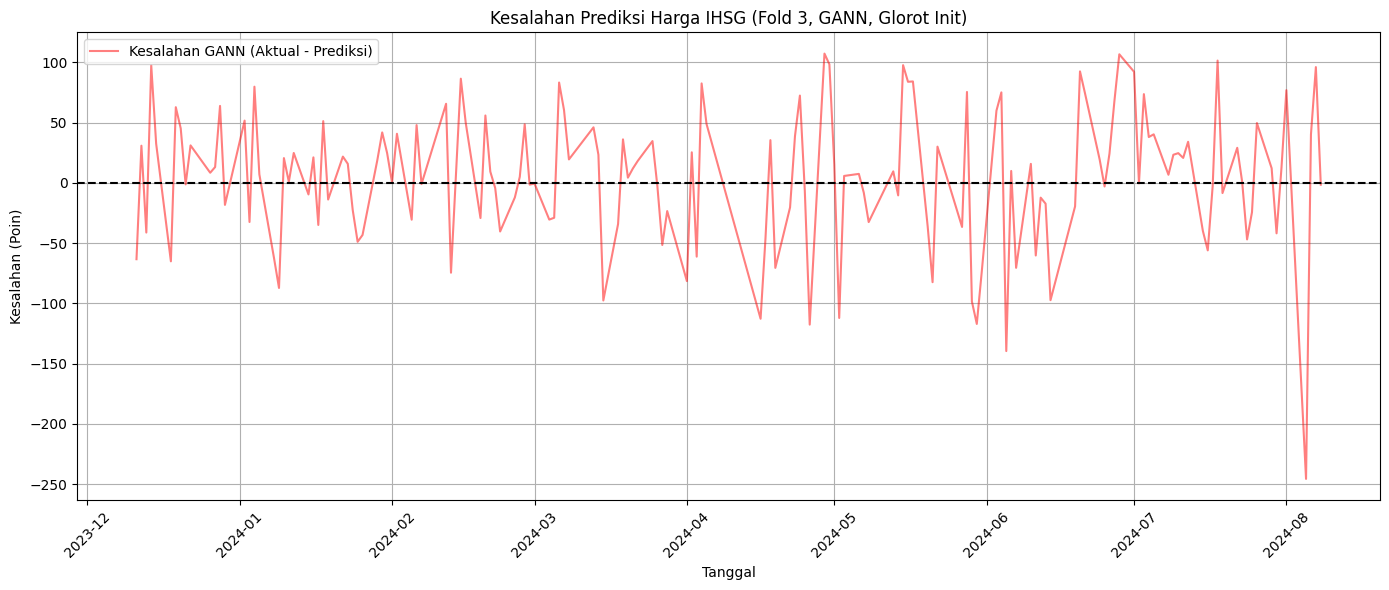

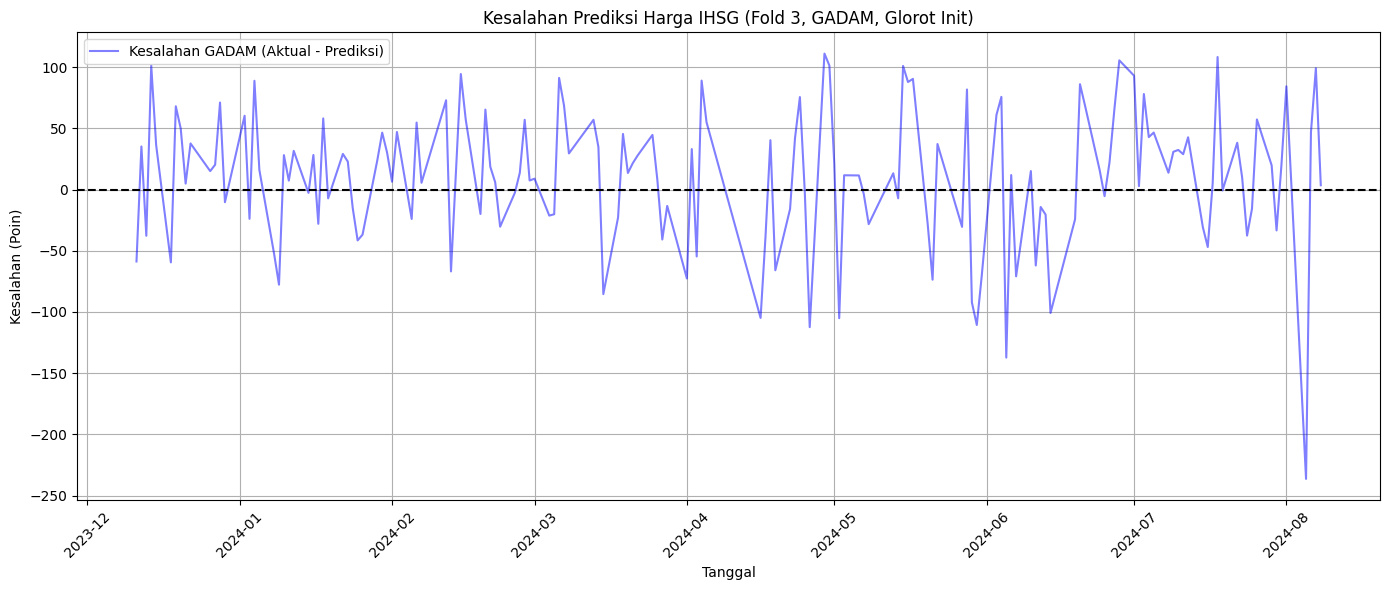

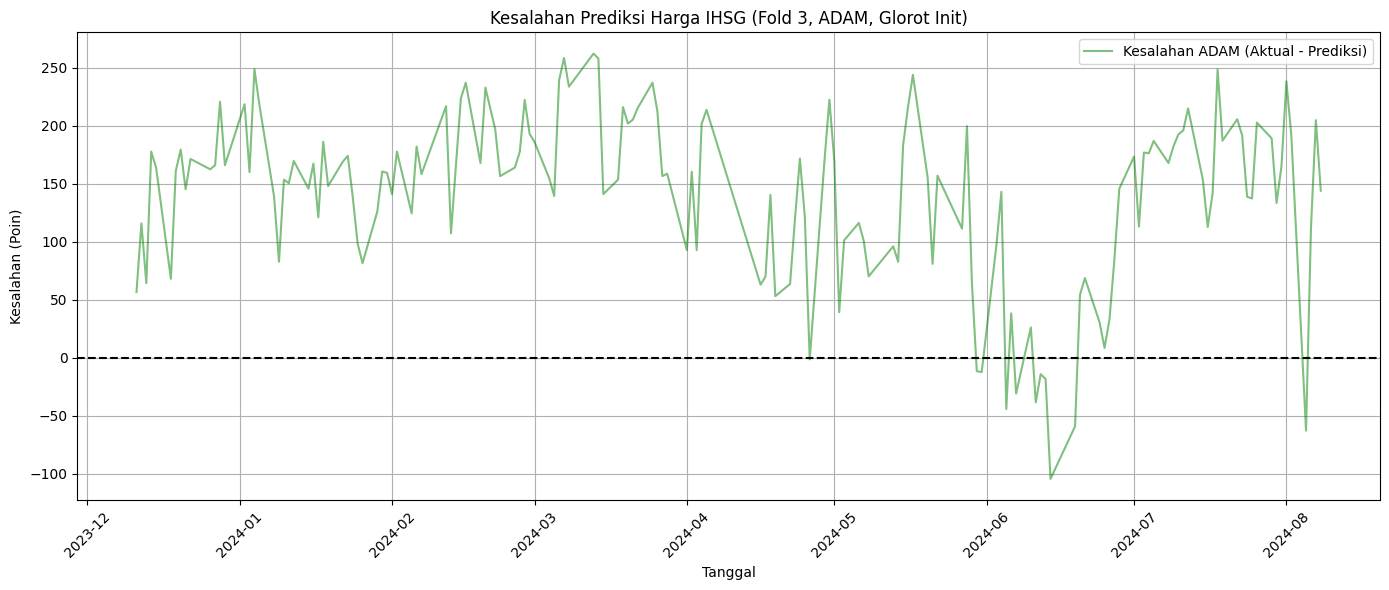

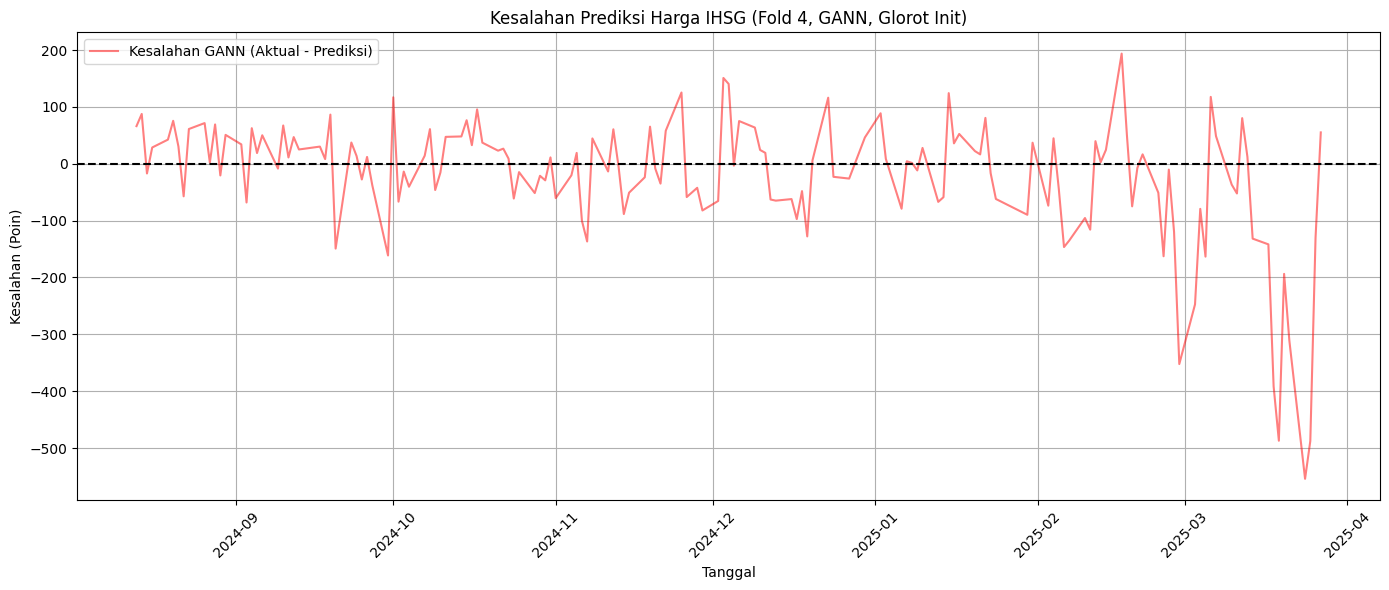

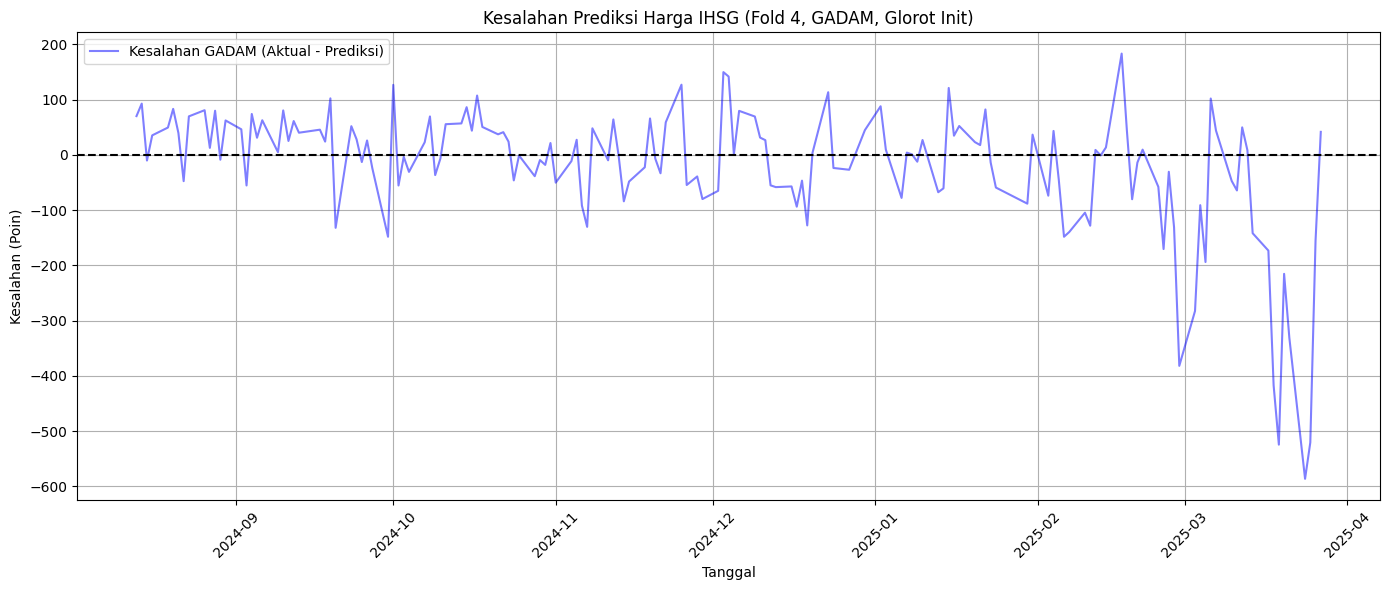

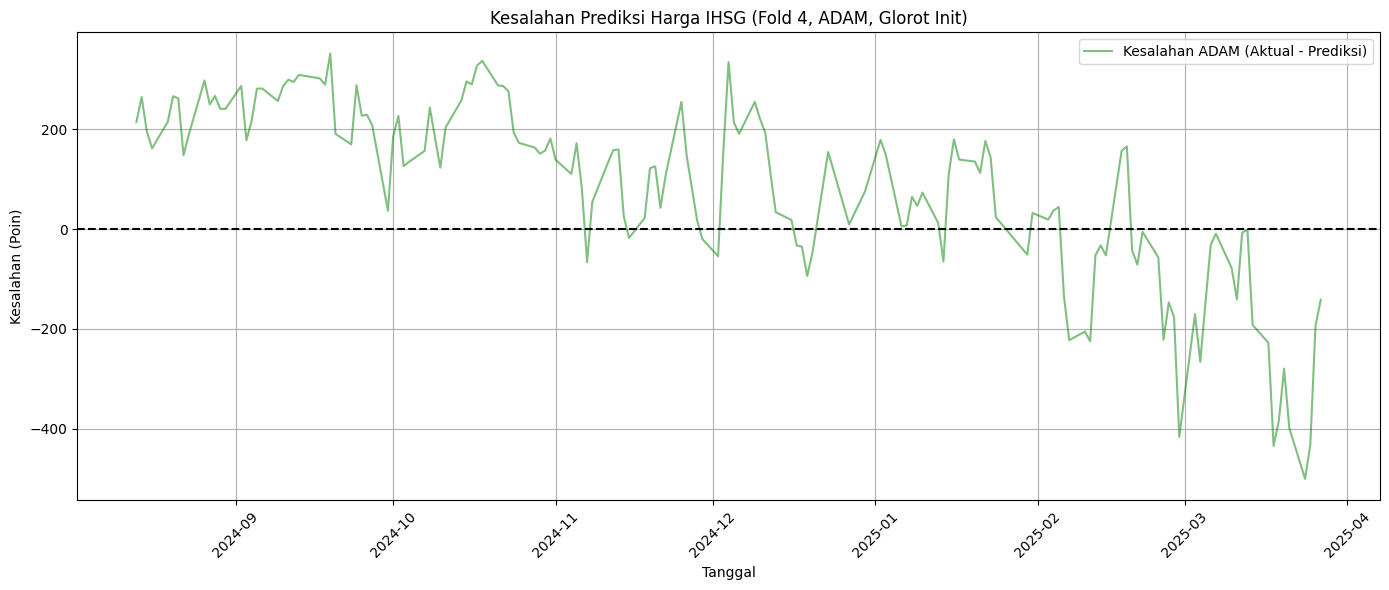


Perbandingan Metrik Evaluasi (Rata-rata):
   Model   Data    RMSE     MAE  MAPE
0   GANN  Latih   54.01   40.74  0.59
1   GANN    Uji   63.99   46.04  0.66
2  GADAM  Latih   53.73   40.64  0.59
3  GADAM    Uji   65.47   46.89  0.67
4   ADAM  Latih   91.14   73.18  1.05
5   ADAM    Uji  128.11  107.67  1.51

Perbandingan Nilai Aktual dan Prediksi (Fold 4):
        Date  Actual_Close  Predicted_GANN  Predicted_GADAM  Predicted_ADAM
0 2022-01-05       6662.30     6693.399758      6702.648943     6714.580212
1 2022-01-06       6653.35     6662.521583      6672.248618     6729.089120
2 2022-01-07       6701.32     6652.909756      6662.929124     6707.028609
3 2022-01-10       6691.12     6698.755859      6707.944968     6707.837847
4 2022-01-11       6647.97     6690.410557      6699.593991     6736.719002
5 2022-01-12       6647.06     6648.615182      6658.617633     6724.480823
6 2022-01-13       6658.36     6646.426060      6656.615618     6697.144817
7 2022-01-14       6693.40     66

In [ ]:
# Gabungkan semua prediksi
all_predictions = []
for fold in range(N_SPLITS):
    gann_df = gann_predictions_per_fold[fold][['Fold', 'Date', 'Actual_Close', 'Predicted_GANN', 'Data']]
    gadam_df = gadam_predictions_per_fold[fold][['Predicted_GADAM']]
    adam_df = adam_predictions_per_fold[fold][['Predicted_ADAM']]
    fold_df = pd.concat([gann_df, gadam_df, adam_df], axis=1)
    all_predictions.append(fold_df)

# Agregasi metrik
metrics_final = pd.DataFrame()
for model_type, metrics in [('GANN', gann_metrics), ('GADAM', gadam_metrics), ('ADAM', adam_metrics)]:
    metrics_df = pd.DataFrame(metrics)
    avg_metrics = metrics_df.groupby('Data')[['RMSE', 'MAE', 'MAPE']].mean().reset_index()
    avg_metrics['Model'] = model_type
    metrics_final = pd.concat([metrics_final, avg_metrics], ignore_index=True)
metrics_final = metrics_final[['Model', 'Data', 'RMSE', 'MAE', 'MAPE']].round(2)

# Simpan metrik
metrics_final.to_csv(f'models/ihsg_metrics_cv_glorot_per_fold.csv', index=False)

# Simpan semua prediksi
all_predictions_df = pd.concat(all_predictions, ignore_index=True)
all_predictions_df.to_csv(f'models/ihsg_predictions_per_fold_glorot.csv', index=False)

# Simpan prediksi fold terakhir
last_fold_df = all_predictions[-1]
pred_df = pd.DataFrame({
    'Date': last_fold_df['Date'],
    'Actual_Close': last_fold_df['Actual_Close'],
    'Predicted_GANN': last_fold_df['Predicted_GANN'],
    'Predicted_GADAM': last_fold_df['Predicted_GADAM'],
    'Predicted_ADAM': last_fold_df['Predicted_ADAM']
})
pred_df.to_csv(f'models/ihsg_predictions_cv_glorot.csv', index=False)

# Simpan bobot terbaik (GANN saja, karena GADAM menggunakan bobot GANN)
weights_df = []
for fold, weights in enumerate(gann_best_weights, 1):
    w1 = np.array(weights[:INPUT_DIM * HIDDEN_NEURONS]).reshape(INPUT_DIM, HIDDEN_NEURONS)
    b1 = np.array(weights[INPUT_DIM * HIDDEN_NEURONS:INPUT_DIM * HIDDEN_NEURONS + HIDDEN_NEURONS])
    w2 = np.array(weights[INPUT_DIM * HIDDEN_NEURONS + HIDDEN_NEURONS:INPUT_DIM * HIDDEN_NEURONS + 2 * HIDDEN_NEURONS]).reshape(HIDDEN_NEURONS, 1)
    b2 = np.array([weights[-1]])
    weights_df.append({
        'Fold': fold,
        'Input_to_Hidden': w1.tolist(),
        'Bias_to_Hidden': b1.tolist(),
        'Hidden_to_Output': w2.tolist(),
        'Bias_to_Output': b2.tolist()
    })
weights_df = pd.DataFrame(weights_df)
weights_df.to_csv(f'models/ihsg_best_weights_gann_glorot.csv', index=False)

# Visualisasi kesalahan prediksi
for fold, data in enumerate(fold_data, 1):
    test_dates = data['test_dates'][WINDOW_SIZE:]
    test_close = data['test_close'][WINDOW_SIZE:]
    fold_df = all_predictions[fold-1]
    for model_type in ['GANN', 'GADAM', 'ADAM']:
        pred_col = f'Predicted_{model_type}'
        error = test_close - fold_df[fold_df['Data'] == 'Uji'][pred_col].values

        plt.figure(figsize=(14, 6))
        plt.plot(test_dates, error, label=f'Kesalahan {model_type} (Aktual - Prediksi)',
                 color='red' if model_type == 'GANN' else 'blue' if model_type == 'GADAM' else 'green', alpha=0.5)
        plt.axhline(0, color='black', linestyle='--')
        plt.title(f'Kesalahan Prediksi Harga IHSG (Fold {fold}, {model_type}, Glorot Init)')
        plt.xlabel('Tanggal')
        plt.ylabel('Kesalahan (Poin)')
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(f'docs/ihsg_prediction_error_{model_type.lower()}_fold_{fold}_glorot.png')
        plt.show()

# Tampilkan hasil
print("\nPerbandingan Metrik Evaluasi (Rata-rata):")
print(metrics_final)
print(f"\nPerbandingan Nilai Aktual dan Prediksi (Fold {N_SPLITS}):")
print(pred_df.head(10))

print("\nMetrik evaluasi disimpan ke 'ihsg_metrics_cv_glorot_per_fold.csv'")
print("Prediksi per fold disimpan ke 'ihsg_predictions_per_fold_glorot.csv'")
print("Prediksi fold terakhir disimpan ke 'ihsg_predictions_cv_glorot.csv'")
print("Model final disimpan di direktori 'models/'")
print("Bobot terbaik disimpan ke 'ihsg_best_weights_gann_glorot.csv'")

## 15. Visualisasi Perbandingan Metrik
Membuat visualisasi perbandingan metrik untuk semua model.

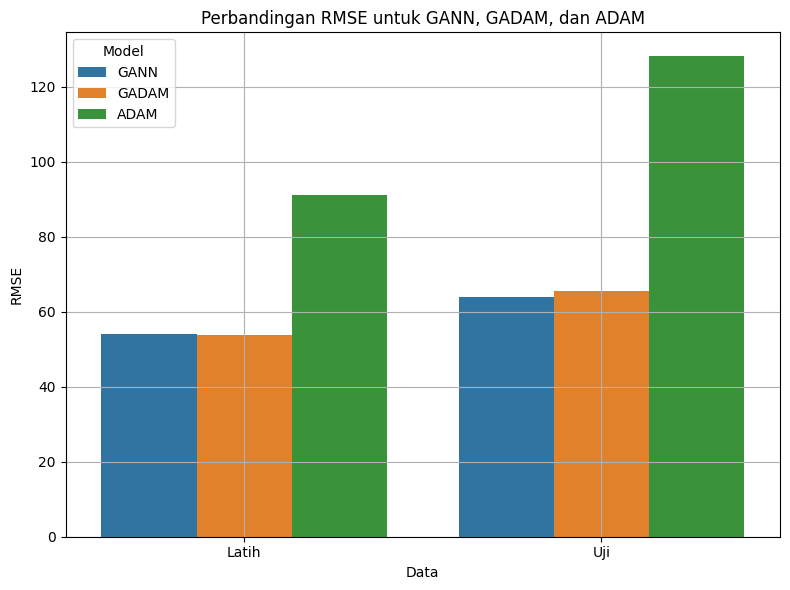

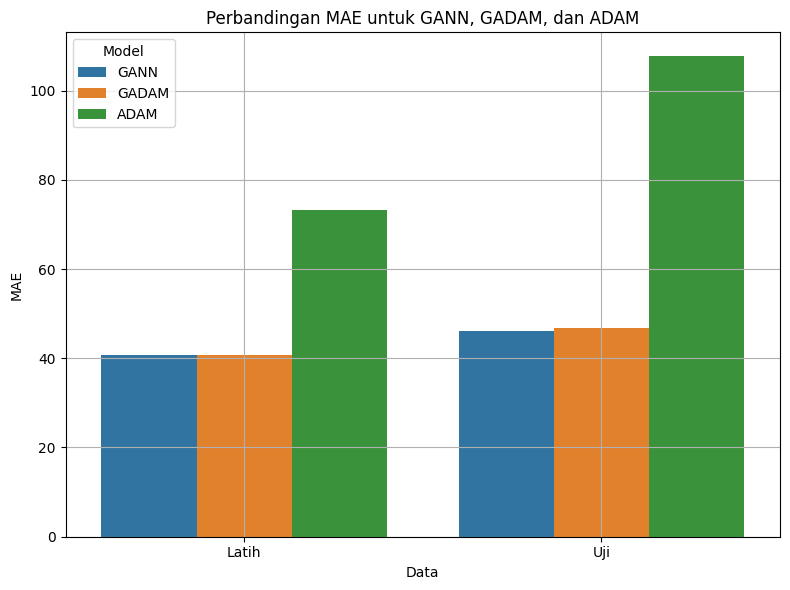

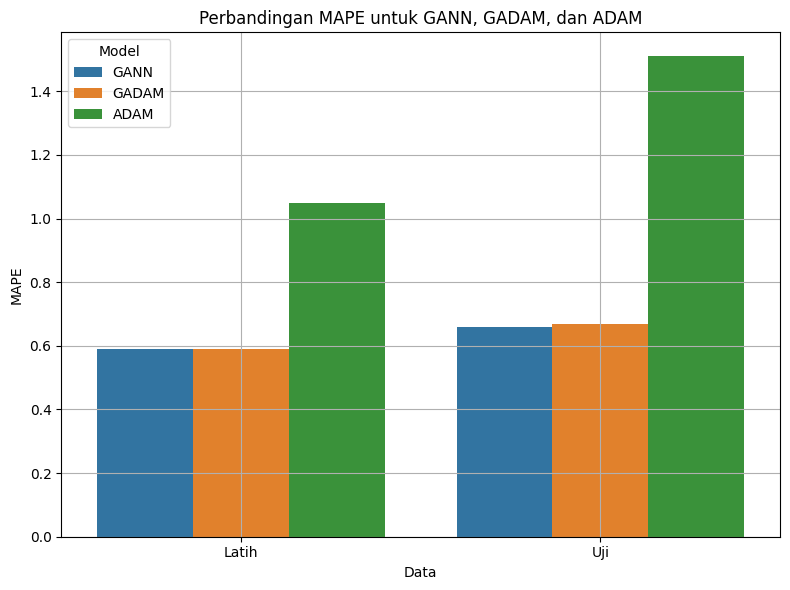

In [ ]:
for metric in ['RMSE', 'MAE', 'MAPE']:
    plt.figure(figsize=(8, 6))
    sns.barplot(data=metrics_final, x='Data', y=metric, hue='Model')
    plt.title(f'Perbandingan {metric} untuk GANN, GADAM, dan ADAM')
    plt.xlabel('Data')
    plt.ylabel(metric)
    plt.legend(title='Model')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'docs/ihsg_metrics_comparison_{metric.lower()}.png')
    plt.show()

In [ ]:
!jupyter nbconvert --to html /content/drive/MyDrive/penelitian/GA-ANN-Final.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/penelitian/GA-ANN-Final.ipynb to html
[NbConvertApp] ERROR | Notebook JSON is invalid: Additional properties are not allowed ('metadata' was unexpected)

Failed validating 'additionalProperties' in stream:

On instance['cells'][38]['outputs'][0]:
{'metadata': {'tags': None},
 'name': 'stdout',
 'output_type': 'stream',
 'text': '[NbConvertApp] Converting notebook '
         '/content/drive/MyDrive/peneli...'}
[NbConvertApp] WARNING | Alternative text is missing on 40 image(s).
[NbConvertApp] Writing 4671200 bytes to /content/drive/MyDrive/penelitian/GA-ANN-Final.html
